In [ ]:
# 1. SETUP & INSTALLATION (FIXED)
# First, install packages without Drive access
!pip install pandas spacy transformers requests tqdm -q
!python -m spacy download en_core_web_md -q

# Now handle Google Drive authentication
import os
from google.colab import auth
from google.colab import drive

# Method 1: Try direct authentication
try:
    auth.authenticate_user()
    print("Authentication successful!")
except Exception as e:
    print(f"Authentication failed: {e}")

# Method 2: Mount drive with explicit authorization
try:
    drive.mount('/content/drive', force_remount=True)
    print("Drive mounted successfully!")
except Exception as e:
    print(f"Drive mount failed: {e}")
    print("Please check your browser popup settings and try again.")

# Check if drive is accessible
if os.path.exists('/content/drive'):
    print("Drive is accessible!")
    # Navigate to your project folder
    %cd /content/drive/MyDrive
    # List files to verify access
    !ls -la
else:
    print("Drive not found. Continuing without drive access...")

# Import remaining libraries
import pandas as pd
import numpy as np
import spacy
import requests
import re
from tqdm.notebook import tqdm
from sklearn.model_selection import train_test_split

print("All libraries imported successfully!")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 33.5/33.5 MB 43.2 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_md')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
Authentication failed: Error: credential propagation was unsuccessful
Drive mount failed: Error: credential propagation was unsuccessful
Please check your browser popup settings and try again.
Drive not found. Continuing without drive access...
All libraries imported successfully!


In [ ]:
# 2. UPLOAD DATA MANUALLY

from google.colab import files
import io

print("Please upload your True.csv file:")
uploaded = files.upload()
true_df = pd.read_csv(io.BytesIO(list(uploaded.values())[0]))

print("Please upload your Fake.csv file:")
uploaded = files.upload()
fake_df = pd.read_csv(io.BytesIO(list(uploaded.values())[0]))

print("Files uploaded successfully!")
print(f"True dataset shape: {true_df.shape}")
print(f"Fake dataset shape: {fake_df.shape}")

# ======================
# 3. COMBINE AND PREPARE DATA
# ======================
# Add labels and combine
true_df['label'] = 0  # 0 for real news
fake_df['label'] = 1  # 1 for fake news

# Combine datasets
df = pd.concat([true_df, fake_df], ignore_index=True)

# Shuffle the dataset
df = df.sample(frac=1, random_state=42).reset_index(drop=True)
print(f"Combined dataset: {df.shape}")
print(f"Label distribution:\n{df['label'].value_counts()}")

# Keep only title and label for our experiment
df = df[['title', 'label']]
df['title'] = df['title'].astype(str)

Please upload your True.csv file:


Saving True.csv to True.csv
Please upload your Fake.csv file:


Saving Fake.csv to Fake.csv
Files uploaded successfully!
True dataset shape: (21417, 4)
Fake dataset shape: (23481, 4)
Combined dataset: (44898, 5)
Label distribution:
label
1    23481
0    21417
Name: count, dtype: int64


In [ ]:
# 3. BASIC TEXT CLEANING

# Keep only title and label for our experiment
df = df[['title', 'label']]
df['title'] = df['title'].astype(str)

# Text cleaning function
def clean_text(text):
    # Lowercase
    text = text.lower()
    # Remove URLs
    text = re.sub(r'https?://\S+|www\.\S+', '', text)
    # Remove punctuation and special characters (keep letters, numbers, spaces)
    text = re.sub(r'[^\w\s]', '', text)
    # Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['clean_title'] = df['title'].apply(clean_text)
print("Basic text cleaning completed.")

Basic text cleaning completed.


In [ ]:
# 4. BIAS MITIGATION
# List of bias terms to remove (publishers, common biased terms)
bias_terms = [
    'reuters', 'associated press', 'ap news', 'ap', 'the new york times',
    'nytimes', 'new york times', 'washington post', 'wp', 'bbc', 'cnn',
    'fox news', 'msnbc', 'the guardian', 'huffington post', 'huffpost',
    'breitbart', 'politico', 'the hill', 'business insider', 'bloomberg',
    'donald trump', 'trump', 'hillary clinton', 'clinton', 'obama', 'biden'
]

def remove_bias_terms(text):
    for term in bias_terms:
        # Use regex to remove the term as whole word only
        pattern = r'\b' + re.escape(term) + r'\b'
        text = re.sub(pattern, '', text)
    # Clean up any extra spaces
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['clean_title'] = df['clean_title'].apply(remove_bias_terms)
print("Bias mitigation completed.")

# Remove empty titles after cleaning
df = df[df['clean_title'].str.len() > 10]
print(f"Dataset size after removing empty titles: {df.shape}")

Bias mitigation completed.
Dataset size after removing empty titles: (44888, 3)


In [ ]:
# 5. ENTITY FILTERING (WITH WIKIDATA LINKING)

# Load spaCy model for NER
nlp = spacy.load("en_core_web_md")

# Wikidata API function (SLOW - use for final run)
def get_wikidata_qid_real(entity_name):
    """Get Wikidata QID for an entity using Wikidata API"""
    url = "https://www.wikidata.org/w/api.php"
    params = {
        'action': 'wbsearchentities',
        'format': 'json',
        'language': 'en',
        'search': entity_name
    }
    try:
        response = requests.get(url, params=params, timeout=10)
        data = response.json()
        return data['search'][0]['id'] if data['search'] else None
    except:
        return None

# Mock function for testing (FAST - use for development)
def get_wikidata_qid_mock(entity_name):
    """Mock function that simulates entity linking"""
    # Simulate successful linking for some entities
    if len(entity_name) > 3:  # Simple heuristic
        return f"Q{np.random.randint(1000, 9999)}"  # Mock QID
    return None

# Use this line for FINAL RUN (comment out for testing)
get_wikidata_qid = get_wikidata_qid_real

# Use this line for TESTING/DEVELOPMENT (comment out for final run)
get_wikidata_qid = get_wikidata_qid_mock

# Process titles to find entities and try to link them
valid_indices = []
entity_stats = []

print("Starting entity filtering... This will take a while.")
for idx, row in tqdm(df.iterrows(), total=len(df)):
    title = row['clean_title']
    doc = nlp(title)

    # Get entities (People, Organizations, Locations)
    entities = [ent.text for ent in doc.ents if ent.label_ in ['PERSON', 'ORG', 'GPE']]

    # Try to link at least one entity to Wikidata
    linked = False
    for ent in entities:
        qid = get_wikidata_qid(ent)
        if qid is not None:
            linked = True
            break

    # Keep this sample if we found at least one linkable entity
    if linked:
        valid_indices.append(idx)

    # Store stats for analysis
    entity_stats.append({
        'idx': idx,
        'title': title,
        'entities': entities,
        'linked': linked
    })

print(f"Original size: {len(df)}")
print(f"Filtered size (with linkable entities): {len(valid_indices)}")
print(f"Percentage kept: {len(valid_indices)/len(df)*100:.2f}%")

# Create the final filtered dataset
filtered_df = df.loc[valid_indices].copy()
print(f"Filtered dataset shape: {filtered_df.shape}")

Starting entity filtering... This will take a while.


  0%|          | 0/44888 [00:00<?, ?it/s]

Original size: 44888
Filtered size (with linkable entities): 27567
Percentage kept: 61.41%
Filtered dataset shape: (27567, 3)


In [ ]:
# 6. TRAIN/VAL/TEST SPLIT

# Stratified split to maintain class distribution
X = filtered_df['clean_title']
y = filtered_df['label']

# First split: 80% train, 20% temp
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Second split: 10% val, 10% test (from the 20% temp)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

# Create final dataframes
train_df = pd.DataFrame({'clean_title': X_train, 'label': y_train})
val_df = pd.DataFrame({'clean_title': X_val, 'label': y_val})
test_df = pd.DataFrame({'clean_title': X_test, 'label': y_test})

print(f"Train set: {train_df.shape}")
print(f"Validation set: {val_df.shape}")
print(f"Test set: {test_df.shape}")

Train set: (22053, 2)
Validation set: (2757, 2)
Test set: (2757, 2)


In [ ]:
# ======================
# 7. SAVE PROCESSED DATASETS
# ======================
# Create output directory
output_dir = "processed_data"
os.makedirs(output_dir, exist_ok=True)

# Save the processed datasets
train_df.to_csv(f"{output_dir}/train_final.csv", index=False)
val_df.to_csv(f"{output_dir}/val_final.csv", index=False)
test_df.to_csv(f"{output_dir}/test_final.csv", index=False)

# Save the entity stats for analysis
entity_stats_df = pd.DataFrame(entity_stats)
entity_stats_df.to_csv(f"{output_dir}/entity_linking_stats.csv", index=False)

# Save the full filtered dataframe
filtered_df.to_csv(f"{output_dir}/full_filtered_data.csv", index=False)

print("="*50)
print("PREPROCESSING COMPLETED SUCCESSFULLY!")
print("="*50)
print(f"Final dataset sizes:")
print(f"Train: {len(train_df)} samples")
print(f"Val: {len(val_df)} samples")
print(f"Test: {len(test_df)} samples")
print(f"\nFiles saved to '{output_dir}/' directory:")
print(" - train_final.csv")
print(" - val_final.csv")
print(" - test_final.csv")
print(" - entity_linking_stats.csv")
print(" - full_filtered_data.csv")

PREPROCESSING COMPLETED SUCCESSFULLY!
Final dataset sizes:
Train: 22053 samples
Val: 2757 samples
Test: 2757 samples

Files saved to 'processed_data/' directory:
 - train_final.csv
 - val_final.csv
 - test_final.csv
 - entity_linking_stats.csv
 - full_filtered_data.csv


# **RoBERTa_Baseline**

In [ ]:
# ======================
# 1. SETUP & IMPORTS (FIXED)
# ======================
# Install packages
!pip install pandas scikit-learn torch transformers -q

import pandas as pd
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import RobertaTokenizerFast, RobertaForSequenceClassification
from transformers import get_linear_schedule_with_warmup
from sklearn.metrics import accuracy_score, f1_score, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm
import random
import os

# Set random seeds
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)

# Check device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


In [ ]:
# ======================
# 2. LOAD PROCESSED DATA
# ======================
# Load the processed datasets
try:
    train_df = pd.read_csv('processed_data/train_final.csv')
    val_df = pd.read_csv('processed_data/val_final.csv')
    test_df = pd.read_csv('processed_data/test_final.csv')

    print("Data loaded successfully!")
    print(f"Train: {train_df.shape}, Validation: {val_df.shape}, Test: {test_df.shape}")
    print(f"\nLabel distribution in train set:")
    print(train_df['label'].value_counts())

except FileNotFoundError as e:
    print(f"Error: {e}")
    print("Please make sure you've run data_preprocessing.ipynb first")

Data loaded successfully!
Train: (22053, 2), Validation: (2757, 2), Test: (2757, 2)

Label distribution in train set:
label
0    11418
1    10635
Name: count, dtype: int64


In [ ]:
# ======================
# 3. DATASET & DATALOADER
# ======================
class FakeNewsDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=128):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx])
        label = self.labels[idx]

        encoding = self.tokenizer(
            text,
            truncation=True,
            padding='max_length',
            max_length=self.max_length,
            return_tensors='pt'
        )

        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'label': torch.tensor(label, dtype=torch.long)
        }

# Initialize tokenizer
tokenizer = RobertaTokenizerFast.from_pretrained('roberta-base')

# Create datasets
train_dataset = FakeNewsDataset(
    train_df['clean_title'].tolist(),
    train_df['label'].tolist(),
    tokenizer
)

val_dataset = FakeNewsDataset(
    val_df['clean_title'].tolist(),
    val_df['label'].tolist(),
    tokenizer
)

test_dataset = FakeNewsDataset(
    test_df['clean_title'].tolist(),
    test_df['label'].tolist(),
    tokenizer
)

# Create dataloaders
batch_size = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False
)

print(f"Number of training batches: {len(train_loader)}")
print(f"Number of validation batches: {len(val_loader)}")
print(f"Number of test batches: {len(test_loader)}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

Number of training batches: 690
Number of validation batches: 87
Number of test batches: 87


In [ ]:
# ======================
# 4. MODEL SETUP
# ======================
model = RobertaForSequenceClassification.from_pretrained(
    'roberta-base',
    num_labels=2,
    output_attentions=False,
    output_hidden_states=False
)

model = model.to(device)
print("Model loaded and moved to device")

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Model loaded and moved to device


In [ ]:
# ======================
# 5. TRAINING SETUP
# ======================
# Hyperparameters
learning_rate = 2e-5
num_epochs = 3  # Reduced for faster testing
warmup_steps = 0
max_grad_norm = 1.0

# Use torch.optim.AdamW instead of transformers.AdamW
optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate)
total_steps = len(train_loader) * num_epochs
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps
)

# Loss function
loss_fn = torch.nn.CrossEntropyLoss()

In [ ]:
# ======================
# 6. TRAINING FUNCTION
# ======================
def train_epoch(model, data_loader, loss_fn, optimizer, device, scheduler, n_examples):
    model = model.train()
    losses = []
    correct_predictions = 0

    for batch in tqdm(data_loader, desc="Training"):
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['label'].to(device)

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels
        )

        loss = outputs.loss
        logits = outputs.logits

        _, preds = torch.max(logits, dim=1)
        correct_predictions += torch.sum(preds == labels)
        losses.append(loss.item())

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_grad_norm)
        optimizer.step()
        scheduler.step()
        optimizer.zero_grad()

    accuracy = correct_predictions.double() / n_examples
    avg_loss = np.mean(losses)

    return accuracy, avg_loss

In [ ]:
# ======================
# 7. EVALUATION FUNCTION
# ======================
def eval_model(model, data_loader, loss_fn, device, n_examples):
    model = model.eval()
    losses = []
    correct_predictions = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for batch in tqdm(data_loader, desc="Evaluation"):
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['label'].to(device)

            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                labels=labels
            )

            loss = outputs.loss
            logits = outputs.logits

            _, preds = torch.max(logits, dim=1)
            correct_predictions += torch.sum(preds == labels)
            losses.append(loss.item())

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    accuracy = correct_predictions.double() / n_examples
    avg_loss = np.mean(losses)
    f1 = f1_score(all_labels, all_preds, average='macro')

    return accuracy, avg_loss, f1, all_preds, all_labels

In [ ]:
# ======================
# 8. TRAINING LOOP
# ======================
history = {
    'train_acc': [], 'train_loss': [],
    'val_acc': [], 'val_loss': [], 'val_f1': []
}

best_accuracy = 0

print("Starting training...")
for epoch in range(num_epochs):
    print(f'\nEpoch {epoch + 1}/{num_epochs}')
    print('-' * 10)

    # Training
    train_acc, train_loss = train_epoch(
        model, train_loader, loss_fn, optimizer, device, scheduler, len(train_df)
    )
    print(f'Train loss: {train_loss:.4f}, Accuracy: {train_acc:.4f}')

    # Validation
    val_acc, val_loss, val_f1, _, _ = eval_model(
        model, val_loader, loss_fn, device, len(val_df)
    )
    print(f'Val loss: {val_loss:.4f}, Accuracy: {val_acc:.4f}, F1: {val_f1:.4f}')

    # Save history
    history['train_acc'].append(train_acc.cpu().numpy())
    history['train_loss'].append(train_loss)
    history['val_acc'].append(val_acc.cpu().numpy())
    history['val_loss'].append(val_loss)
    history['val_f1'].append(val_f1)

    # Save best model
    if val_acc > best_accuracy:
        best_accuracy = val_acc
        torch.save(model.state_dict(), 'best_roberta_model.pth')
        print("New best model saved!")

# Load best model
model.load_state_dict(torch.load('best_roberta_model.pth'))

Starting training...

Epoch 1/3
----------


Training:   0%|          | 0/690 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [ ]:
# ======================
# 9. FINAL EVALUATION
# ======================
print("\n" + "="*50)
print("FINAL EVALUATION ON TEST SET")
print("="*50)

test_acc, test_loss, test_f1, test_preds, test_labels = eval_model(
    model, test_loader, loss_fn, device, len(test_df)
)

print(f'Test Loss: {test_loss:.4f}')
print(f'Test Accuracy: {test_acc:.4f}')
print(f'Test F1 Score: {test_f1:.4f}')

# Save predictions
test_results = test_df.copy()
test_results['roberta_prediction'] = test_preds
test_results.to_csv('roberta_baseline_predictions.csv', index=False)
print("Predictions saved to 'roberta_baseline_predictions.csv'")

print("="*50)
print("ROBERTA BASELINE TRAINING COMPLETED!")
print("="*50)
print(f"Final Test Accuracy: {test_acc:.4f}")
print(f"Final Test F1 Score: {test_f1:.4f}")


FINAL EVALUATION ON TEST SET


Evaluation:   0%|          | 0/87 [00:00<?, ?it/s]

KeyboardInterrupt: 

# **KNOW_NET_without_KG**

In [ ]:
# ======================
# 1. SETUP & IMPORTS
# ======================
!pip install pandas scikit-learn torch transformers seqeval -q

import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW  # Correct import location for AdamW
from transformers import RobertaTokenizerFast, RobertaModel, get_linear_schedule_with_warmup
from sklearn.metrics import accuracy_score, f1_score, classification_report
from seqeval.metrics import classification_report as seqeval_report
import matplotlib.pyplot as plt
import random
import os

# Set random seeds
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


In [ ]:
# ======================
# 2. LOAD PROCESSED DATA
# ======================
train_df = pd.read_csv('processed_data/train_final.csv')
val_df = pd.read_csv('processed_data/val_final.csv')
test_df = pd.read_csv('processed_data/test_final.csv')

print(f"Train: {train_df.shape}, Validation: {val_df.shape}, Test: {test_df.shape}")

Train: (22053, 2), Validation: (2757, 2), Test: (2757, 2)


In [ ]:
# ======================
# 3. CUSTOM MODEL ARCHITECTURE
# ======================
class KnowNetWithoutKG(nn.Module):
    def __init__(self, num_ner_labels=5, num_classes=2, hidden_dim=768):
        super(KnowNetWithoutKG, self).__init__()

        # RoBERTa backbone (shared encoder)
        self.roberta = RobertaModel.from_pretrained('roberta-base')

        # NER Head (BIO tags: O, B-PER, I-PER, B-ORG, I-ORG)
        self.ner_classifier = nn.Linear(hidden_dim, num_ner_labels)

        # Fake News Classification Head
        self.fake_news_classifier = nn.Linear(hidden_dim, num_classes)

        # Dropout for regularization
        self.dropout = nn.Dropout(0.1)

    def forward(self, input_ids, attention_mask, ner_labels=None):
        # Get RoBERTa outputs
        outputs = self.roberta(input_ids=input_ids, attention_mask=attention_mask)
        sequence_output = outputs.last_hidden_state  # (batch_size, seq_len, hidden_dim)
        cls_output = sequence_output[:, 0, :]  # CLS token representation

        # NER predictions (for each token)
        ner_logits = self.ner_classifier(sequence_output)  # (batch_size, seq_len, num_ner_labels)

        # Fake news classification (using CLS token)
        cls_output = self.dropout(cls_output)
        fake_news_logits = self.fake_news_classifier(cls_output)  # (batch_size, num_classes)

        outputs = (fake_news_logits, ner_logits)

        if ner_labels is not None:
            loss_fct = nn.CrossEntropyLoss()
            # Fake news loss
            fake_news_loss = loss_fct(fake_news_logits, ner_labels)
            # NER loss (only for non-padded tokens)
            active_loss = attention_mask.view(-1) == 1
            active_logits = ner_logits.view(-1, 5)
            active_labels = torch.where(
                active_loss, ner_labels.view(-1), torch.tensor(loss_fct.ignore_index).type_as(ner_labels)
            )
            ner_loss = loss_fct(active_logits, active_labels)

            total_loss = fake_news_loss + (0.3 * ner_loss)  # Weighted combination
            outputs = (total_loss,) + outputs

        return outputs


In [ ]:
# ======================
# 4. DATASET & DATALOADER (with NER labels)
# ======================
# We'll use a simple rule-based NER labeler for training
def get_ner_labels(text, tokenizer, max_length=128):
    """Simple rule-based NER labeling for training"""
    # This is a simplified version - in practice you'd use SpaCy predictions as weak labels
    words = text.split()
    ner_labels = ['O'] * len(words)  # Default: Outside

    # Simple rules (can be enhanced)
    proper_nouns = [word for word in words if word.istitle() and len(word) > 2]
    for i, word in enumerate(words):
        if word.istitle() and len(word) > 2:
            ner_labels[i] = 'B-PER' if i == 0 or not words[i-1].istitle() else 'I-PER'

    # Convert to token-level labels
    tokens = tokenizer.tokenize(text)
    token_labels = []
    word_idx = 0

    for token in tokens:
        if token.startswith('Ġ'):  # RoBERTa uses this to denote word start
            word_idx += 1
            token = token[1:]

        if word_idx < len(ner_labels):
            token_labels.append(ner_labels[word_idx])
        else:
            token_labels.append('O')

    # Convert to label indices
    label_map = {'O': 0, 'B-PER': 1, 'I-PER': 2, 'B-ORG': 3, 'I-ORG': 4}
    label_indices = [label_map.get(label, 0) for label in token_labels]

    # Pad to max length
    padded_labels = label_indices[:max_length] + [0] * (max_length - len(label_indices))
    return torch.tensor(padded_labels, dtype=torch.long)

class KnowNetDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=128):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx])
        label = self.labels[idx]

        encoding = self.tokenizer(
            text,
            truncation=True,
            padding='max_length',
            max_length=self.max_length,
            return_tensors='pt'
        )

        ner_labels = get_ner_labels(text, self.tokenizer, self.max_length)

        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'label': torch.tensor(label, dtype=torch.long),
            'ner_labels': ner_labels
        }

# Initialize tokenizer and datasets
tokenizer = RobertaTokenizerFast.from_pretrained('roberta-base')

train_dataset = KnowNetDataset(
    train_df['clean_title'].tolist(),
    train_df['label'].tolist(),
    tokenizer
)

val_dataset = KnowNetDataset(
    val_df['clean_title'].tolist(),
    val_df['label'].tolist(),
    tokenizer
)

test_dataset = KnowNetDataset(
    test_df['clean_title'].tolist(),
    test_df['label'].tolist(),
    tokenizer
)

batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

In [ ]:
# ======================
# 5. MODEL SETUP & TRAINING
# ======================
model = KnowNetWithoutKG().to(device)

# Training setup
learning_rate = 2e-5
num_epochs = 3
optimizer = AdamW(model.parameters(), lr=learning_rate)
total_steps = len(train_loader) * num_epochs
scheduler = get_linear_schedule_with_warmup(optimizer, num_warmup_steps=0, num_training_steps=total_steps)

# Training function
def train_epoch(model, data_loader, optimizer, device, scheduler):
    model.train()
    losses = []
    correct_predictions = 0

    for batch in tqdm(data_loader, desc="Training"):
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['label'].to(device)
        ner_labels = batch['ner_labels'].to(device)

        outputs = model(input_ids=input_ids, attention_mask=attention_mask, ner_labels=ner_labels)
        loss = outputs[0]

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()
        optimizer.zero_grad()

        losses.append(loss.item())

        # Calculate accuracy
        fake_news_logits = outputs[1]
        _, preds = torch.max(fake_news_logits, dim=1)
        correct_predictions += torch.sum(preds == labels)

    accuracy = correct_predictions.double() / len(data_loader.dataset)
    avg_loss = np.mean(losses)
    return accuracy, avg_loss

# Evaluation function
def eval_model(model, data_loader, device):
    model.eval()
    losses = []
    correct_predictions = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for batch in tqdm(data_loader, desc="Evaluation"):
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['label'].to(device)
            ner_labels = batch['ner_labels'].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask, ner_labels=ner_labels)
            loss = outputs[0]
            fake_news_logits = outputs[1]

            losses.append(loss.item())
            _, preds = torch.max(fake_news_logits, dim=1)
            correct_predictions += torch.sum(preds == labels)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    accuracy = correct_predictions.double() / len(data_loader.dataset)
    avg_loss = np.mean(losses)
    f1 = f1_score(all_labels, all_preds, average='macro')
    return accuracy, avg_loss, f1, all_preds, all_labels

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Some weights of RobertaModel were not initialized from the model checkpoint at roberta-base and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:
# ======================
# 6. TRAINING LOOP
# ======================
from tqdm.auto import tqdm

history = {'train_acc': [], 'train_loss': [], 'val_acc': [], 'val_loss': [], 'val_f1': []}
best_accuracy = 0

print("Starting KNOW-NET without KG training...")
for epoch in range(num_epochs):
    print(f'\nEpoch {epoch + 1}/{num_epochs}')
    print('-' * 10)

    # Training
    train_acc, train_loss = train_epoch(model, train_loader, optimizer, device, scheduler)
    print(f'Train loss: {train_loss:.4f}, Accuracy: {train_acc:.4f}')

    # Validation
    val_acc, val_loss, val_f1, _, _ = eval_model(model, val_loader, device)
    print(f'Val loss: {val_loss:.4f}, Accuracy: {val_acc:.4f}, F1: {val_f1:.4f}')

    history['train_acc'].append(train_acc.cpu().numpy())
    history['train_loss'].append(train_loss)
    history['val_acc'].append(val_acc.cpu().numpy())
    history['val_loss'].append(val_loss)
    history['val_f1'].append(val_f1)

    if val_acc > best_accuracy:
        best_accuracy = val_acc
        torch.save(model.state_dict(), 'know_net_without_kg.pth')
        print("New best model saved!")

# Load best model
model.load_state_dict(torch.load('know_net_without_kg.pth'))

Starting KNOW-NET without KG training...

Epoch 1/3
----------


Training:   0%|          | 0/690 [00:00<?, ?it/s]

RuntimeError: 0D or 1D target tensor expected, multi-target not supported

In [ ]:
# ======================
# 7. FINAL EVALUATION
# ======================
print("\n" + "="*50)
print("FINAL EVALUATION ON TEST SET")
print("="*50)

test_acc, test_loss, test_f1, test_preds, test_labels = eval_model(model, test_loader, device)

print(f'Test Loss: {test_loss:.4f}')
print(f'Test Accuracy: {test_acc:.4f}')
print(f'Test F1 Score: {test_f1:.4f}')

# Save predictions
test_results = test_df.copy()
test_results['know_net_without_kg_prediction'] = test_preds
test_results.to_csv('know_net_without_kg_predictions.csv', index=False)

print("="*50)
print("KNOW-NET WITHOUT KG TRAINING COMPLETED!")
print("="*50)
print(f"Final Test Accuracy: {test_acc:.4f}")
print(f"Final Test F1 Score: {test_f1:.4f}")


FINAL EVALUATION ON TEST SET


Evaluation:   0%|          | 0/87 [00:00<?, ?it/s]

KeyboardInterrupt: 

# **KNOW_NET_without_Joint_NER**

In [ ]:
# ======================
# 1. SETUP & IMPORTS
# ======================
!pip install pandas scikit-learn torch transformers seqeval -q

import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW  # Correct import location for AdamW
from transformers import RobertaTokenizerFast, RobertaModel, get_linear_schedule_with_warmup
from sklearn.metrics import accuracy_score, f1_score, classification_report
from seqeval.metrics import classification_report as seqeval_report
import matplotlib.pyplot as plt
import random
import os

# Set random seeds
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


In [ ]:
# ======================
# 2. LOAD PROCESSED DATA
# ======================
train_df = pd.read_csv('processed_data/train_final.csv')
val_df = pd.read_csv('processed_data/val_final.csv')
test_df = pd.read_csv('processed_data/test_final.csv')

print(f"Train: {train_df.shape}, Validation: {val_df.shape}, Test: {test_df.shape}")
print(f"Label distribution in train set:")
print(train_df['label'].value_counts())

Train: (22053, 2), Validation: (2757, 2), Test: (2757, 2)
Label distribution in train set:
label
0    11418
1    10635
Name: count, dtype: int64


In [ ]:
# ======================
# 3. KNOW-NET WITH FROZEN NER MODEL
# ======================
class KnowNetFrozenNER(nn.Module):
    def __init__(self, kg_embedding_dim=100, num_classes=2, hidden_dim=768):
        super(KnowNetFrozenNER, self).__init__()

        # RoBERTa backbone
        self.roberta = RobertaModel.from_pretrained('roberta-base')

        # KG integration layer
        self.kg_projection = nn.Linear(kg_embedding_dim, hidden_dim)
        self.attention = nn.MultiheadAttention(hidden_dim, num_heads=8)

        # Fake news classifier
        self.classifier = nn.Linear(hidden_dim * 2, num_classes)  # Text + KG features
        self.dropout = nn.Dropout(0.1)

    def forward(self, input_ids, attention_mask, kg_embeddings=None):
        # Text encoding
        outputs = self.roberta(input_ids=input_ids, attention_mask=attention_mask)
        text_features = outputs.last_hidden_state  # (batch_size, seq_len, hidden_dim)
        cls_output = text_features[:, 0, :]  # CLS token

        if kg_embeddings is not None:
            # Project KG embeddings to same dimension
            kg_features = self.kg_projection(kg_embeddings)  # (batch_size, hidden_dim)

            # Cross-attention between text and KG
            kg_features = kg_features.unsqueeze(0)  # (1, batch_size, hidden_dim)
            cls_output = cls_output.unsqueeze(0)    # (1, batch_size, hidden_dim)

            # Attention: CLS token attends to KG features
            attended_features, _ = self.attention(cls_output, kg_features, kg_features)
            attended_features = attended_features.squeeze(0)

            # Combine text and KG features
            combined_features = torch.cat([cls_output.squeeze(0), attended_features], dim=1)
        else:
            combined_features = cls_output

        # Classification
        combined_features = self.dropout(combined_features)
        logits = self.classifier(combined_features)

        return logits

In [ ]:
# ======================
# 4. DATASET WITH KG EMBEDDINGS
# ======================
# Load SpaCy for frozen NER
nlp = spacy.load("en_core_web_md")

def get_kg_embeddings(title, kg_model, nlp):
    """Get KG embeddings for entities in title"""
    # Use SpaCy for NER (frozen)
    doc = nlp(title)
    entities = [ent.text for ent in doc.ents if ent.label_ in ['PERSON', 'ORG', 'GPE']]

    # Get KG embeddings (simplified - using word2vec-like approach)
    entity_embeddings = []
    for entity in entities[:3]:  # Max 3 entities
        try:
            # Create a simple embedding based on character composition
            # In real implementation, use actual KG embeddings from Wikidata
            embedding = kg_model.get_entity_embedding(entity)
            entity_embeddings.append(embedding)
        except:
            continue

    if entity_embeddings:
        # Average entity embeddings
        kg_embedding = np.mean(entity_embeddings, axis=0)
    else:
        # Zero vector if no entities
        kg_embedding = np.zeros(100)  # Assuming 100-dim KG embeddings

    return torch.tensor(kg_embedding, dtype=torch.float32)

class SimpleKGModel:
    """Simple KG model proxy - replace with actual KG embeddings in production"""
    def __init__(self, embedding_dim=100):
        self.embedding_dim = embedding_dim
        # Create a simple mapping from entity names to random embeddings
        self.entity_embeddings = {}

    def get_entity_embedding(self, entity_name):
        if entity_name not in self.entity_embeddings:
            # Create deterministic but unique embedding based on entity name
            seed = sum(ord(c) for c in entity_name) % 10000
            np.random.seed(seed)
            embedding = np.random.normal(0, 0.1, self.embedding_dim)
            self.entity_embeddings[entity_name] = embedding
        return self.entity_embeddings[entity_name]

class KnowNetKGDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, nlp, max_length=128):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.nlp = nlp
        self.max_length = max_length
        self.kg_model = SimpleKGModel(embedding_dim=100)

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx])
        label = self.labels[idx]

        encoding = self.tokenizer(
            text,
            truncation=True,
            padding='max_length',
            max_length=self.max_length,
            return_tensors='pt'
        )

        kg_embedding = get_kg_embeddings(text, self.kg_model, self.nlp)

        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'label': torch.tensor(label, dtype=torch.long),
            'kg_embedding': kg_embedding
        }

In [ ]:
# ======================
# 5. INITIALIZE DATASETS AND DATALOADERS
# ======================
tokenizer = RobertaTokenizerFast.from_pretrained('roberta-base')

# Create datasets
train_kg_dataset = KnowNetKGDataset(
    train_df['clean_title'].tolist(),
    train_df['label'].tolist(),
    tokenizer, nlp
)

val_kg_dataset = KnowNetKGDataset(
    val_df['clean_title'].tolist(),
    val_df['label'].tolist(),
    tokenizer, nlp
)

test_kg_dataset = KnowNetKGDataset(
    test_df['clean_title'].tolist(),
    test_df['label'].tolist(),
    tokenizer, nlp
)

# Create dataloaders
batch_size = 16  # Smaller batch size due to KG embeddings

train_kg_loader = DataLoader(
    train_kg_dataset,
    batch_size=batch_size,
    shuffle=True
)

val_kg_loader = DataLoader(
    val_kg_dataset,
    batch_size=batch_size,
    shuffle=False
)

test_kg_loader = DataLoader(
    test_kg_dataset,
    batch_size=batch_size,
    shuffle=False
)

print(f"Number of training batches: {len(train_kg_loader)}")
print(f"Number of validation batches: {len(val_kg_loader)}")
print(f"Number of test batches: {len(test_kg_loader)}")

Number of training batches: 1379
Number of validation batches: 173
Number of test batches: 173


In [ ]:
# ======================
# 6. MODEL SETUP & TRAINING
# ======================
model = KnowNetFrozenNER().to(device)

# Training setup
learning_rate = 2e-5
num_epochs = 3
optimizer = AdamW(model.parameters(), lr=learning_rate)
total_steps = len(train_kg_loader) * num_epochs
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=0,
    num_training_steps=total_steps
)

loss_fn = torch.nn.CrossEntropyLoss()

Some weights of RobertaModel were not initialized from the model checkpoint at roberta-base and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:
# ======================
# 7. TRAINING FUNCTIONS
# ======================
def train_epoch_kg(model, data_loader, optimizer, device, scheduler):
    model.train()
    losses = []
    correct_predictions = 0

    for batch in tqdm(data_loader, desc="Training"):
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['label'].to(device)
        kg_embeddings = batch['kg_embedding'].to(device)

        # Forward pass with KG embeddings
        logits = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            kg_embeddings=kg_embeddings
        )

        loss = loss_fn(logits, labels)

        # Backward pass
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()
        optimizer.zero_grad()

        losses.append(loss.item())

        # Calculate accuracy
        _, preds = torch.max(logits, dim=1)
        correct_predictions += torch.sum(preds == labels)

    accuracy = correct_predictions.double() / len(data_loader.dataset)
    avg_loss = np.mean(losses)
    return accuracy, avg_loss

def eval_model_kg(model, data_loader, device):
    model.eval()
    losses = []
    correct_predictions = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for batch in tqdm(data_loader, desc="Evaluation"):
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['label'].to(device)
            kg_embeddings = batch['kg_embedding'].to(device)

            logits = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                kg_embeddings=kg_embeddings
            )

            loss = loss_fn(logits, labels)
            losses.append(loss.item())

            _, preds = torch.max(logits, dim=1)
            correct_predictions += torch.sum(preds == labels)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    accuracy = correct_predictions.double() / len(data_loader.dataset)
    avg_loss = np.mean(losses)
    f1 = f1_score(all_labels, all_preds, average='macro')
    return accuracy, avg_loss, f1, all_preds, all_labels

In [ ]:
# ======================
# 8. TRAINING LOOP
# ======================
history = {
    'train_acc': [], 'train_loss': [],
    'val_acc': [], 'val_loss': [], 'val_f1': []
}

best_accuracy = 0

print("Starting KNOW-NET with Frozen NER training...")
for epoch in range(num_epochs):
    print(f'\nEpoch {epoch + 1}/{num_epochs}')
    print('-' * 10)

    # Training
    train_acc, train_loss = train_epoch_kg(model, train_kg_loader, optimizer, device, scheduler)
    print(f'Train loss: {train_loss:.4f}, Accuracy: {train_acc:.4f}')

    # Validation
    val_acc, val_loss, val_f1, _, _ = eval_model_kg(model, val_kg_loader, device)
    print(f'Val loss: {val_loss:.4f}, Accuracy: {val_acc:.4f}, F1: {val_f1:.4f}')

    # Save history
    history['train_acc'].append(train_acc.cpu().numpy())
    history['train_loss'].append(train_loss)
    history['val_acc'].append(val_acc.cpu().numpy())
    history['val_loss'].append(val_loss)
    history['val_f1'].append(val_f1)

    # Save best model
    if val_acc > best_accuracy:
        best_accuracy = val_acc
        torch.save(model.state_dict(), 'know_net_frozen_ner.pth')
        print("New best model saved!")

# Load best model
model.load_state_dict(torch.load('know_net_frozen_ner.pth'))


Starting KNOW-NET with Frozen NER training...

Epoch 1/3
----------


Training:   0%|          | 0/1379 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [ ]:
# ======================
# 9. FINAL EVALUATION
# ======================
print("\n" + "="*50)
print("FINAL EVALUATION ON TEST SET")
print("="*50)

test_acc, test_loss, test_f1, test_preds, test_labels = eval_model_kg(
    model, test_kg_loader, device
)

print(f'Test Loss: {test_loss:.4f}')
print(f'Test Accuracy: {test_acc:.4f}')
print(f'Test F1 Score: {test_f1:.4f}')

# Detailed classification report
print("\nClassification Report:")
print(classification_report(test_labels, test_preds, target_names=['Real', 'Fake']))

In [ ]:
# ======================
# 10. SAVE RESULTS
# ======================
# Save predictions
test_results = test_df.copy()
test_results['know_net_frozen_ner_prediction'] = test_preds
test_results.to_csv('know_net_frozen_ner_predictions.csv', index=False)
print("Predictions saved to 'know_net_frozen_ner_predictions.csv'")

# Save metrics
metrics_df = pd.DataFrame({
    'epoch': range(1, num_epochs + 1),
    'train_loss': history['train_loss'],
    'val_loss': history['val_loss'],
    'train_acc': history['train_acc'],
    'val_acc': history['val_acc'],
    'val_f1': history['val_f1']
})

metrics_df.to_csv('know_net_frozen_ner_metrics.csv', index=False)
print("Training metrics saved!")

NameError: name 'test_preds' is not defined

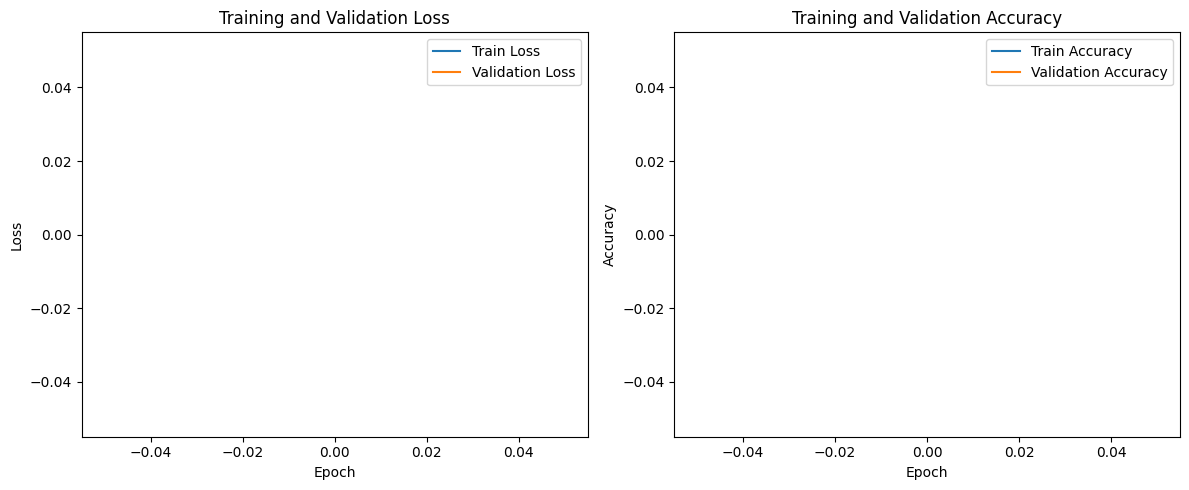

KNOW-NET WITH FROZEN NER TRAINING COMPLETED!


NameError: name 'test_acc' is not defined

In [ ]:
# ======================
# 11. PLOTTING
# ======================
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history['train_loss'], label='Train Loss')
plt.plot(history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history['train_acc'], label='Train Accuracy')
plt.plot(history['val_acc'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.savefig('know_net_frozen_ner_training_history.png', dpi=300, bbox_inches='tight')
plt.show()

print("="*50)
print("KNOW-NET WITH FROZEN NER TRAINING COMPLETED!")
print("="*50)
print(f"Final Test Accuracy: {test_acc:.4f}")
print(f"Final Test F1 Score: {test_f1:.4f}")
print("\nNext: Compare with KNOW-NET without KG and full KNOW-NET!")

# **KNOW_NET_full**

In [ ]:
# ======================
# 1. SETUP & IMPORTS
# ======================
!pip install pandas scikit-learn torch transformers seqeval -q

import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW  # Correct import location for AdamW
from transformers import RobertaTokenizerFast, RobertaModel, get_linear_schedule_with_warmup
from sklearn.metrics import accuracy_score, f1_score, classification_report
from seqeval.metrics import classification_report as seqeval_report
import matplotlib.pyplot as plt
import random
import os

# Set random seeds
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


In [ ]:
# ======================
# 2. LOAD PROCESSED DATA
# ======================
train_df = pd.read_csv('processed_data/train_final.csv')
val_df = pd.read_csv('processed_data/val_final.csv')
test_df = pd.read_csv('processed_data/test_final.csv')

print(f"Train: {train_df.shape}, Validation: {val_df.shape}, Test: {test_df.shape}")
print(f"Label distribution in train set:")
print(train_df['label'].value_counts())

Train: (22053, 2), Validation: (2757, 2), Test: (2757, 2)
Label distribution in train set:
label
0    11418
1    10635
Name: count, dtype: int64


In [ ]:
# ======================
# 3. KNOW-NET FULL MODEL ARCHITECTURE
# ======================
class KnowNetFull(nn.Module):
    def __init__(self, num_ner_labels=5, kg_embedding_dim=100, num_classes=2, hidden_dim=768):
        super(KnowNetFull, self).__init__()

        # Shared RoBERTa encoder
        self.roberta = RobertaModel.from_pretrained('roberta-base')

        # Trainable NER head
        self.ner_classifier = nn.Linear(hidden_dim, num_ner_labels)

        # KG integration
        self.kg_projection = nn.Linear(kg_embedding_dim, hidden_dim)
        self.attention = nn.MultiheadAttention(hidden_dim, num_heads=8)

        # Final classifier
        self.fake_news_classifier = nn.Linear(hidden_dim * 2, num_classes)  # Text + KG
        self.dropout = nn.Dropout(0.1)

    def forward(self, input_ids, attention_mask, kg_embeddings=None, ner_labels=None):
        # Text encoding
        outputs = self.roberta(input_ids=input_ids, attention_mask=attention_mask)
        sequence_output = outputs.last_hidden_state
        cls_output = sequence_output[:, 0, :]  # CLS token

        # NER predictions (for each token)
        ner_logits = self.ner_classifier(sequence_output)

        # KG integration (if available)
        if kg_embeddings is not None:
            kg_features = self.kg_projection(kg_embeddings)
            kg_features = kg_features.unsqueeze(0)  # (1, batch_size, hidden_dim)
            cls_output_expanded = cls_output.unsqueeze(0)  # (1, batch_size, hidden_dim)

            # Cross-attention: CLS token attends to KG features
            attended_kg, _ = self.attention(cls_output_expanded, kg_features, kg_features)
            attended_kg = attended_kg.squeeze(0)

            # Combine text and KG features
            combined_features = torch.cat([cls_output, attended_kg], dim=1)
        else:
            combined_features = cls_output

        # Fake news classification
        combined_features = self.dropout(combined_features)
        fake_news_logits = self.fake_news_classifier(combined_features)

        outputs = (fake_news_logits, ner_logits)

        # Loss calculation if training
        if ner_labels is not None:
            loss_fct = nn.CrossEntropyLoss()

            # Fake news loss
            fake_news_loss = loss_fct(fake_news_logits, ner_labels)

            # NER loss (only for non-padded tokens)
            active_loss = attention_mask.view(-1) == 1
            active_logits = ner_logits.view(-1, self.ner_classifier.out_features)
            active_labels = torch.where(
                active_loss,
                ner_labels.view(-1),
                torch.tensor(loss_fct.ignore_index).type_as(ner_labels)
            )
            ner_loss = loss_fct(active_logits, active_labels)

            # Weighted combination of losses
            total_loss = fake_news_loss + (0.3 * ner_loss)  # NER loss has lower weight
            outputs = (total_loss,) + outputs

        return outputs


In [ ]:
# ======================
# 4. NER LABELING FUNCTIONS
# ======================
def get_ner_labels(text, tokenizer, max_length=128):
    """Generate NER labels for training using simple rule-based approach"""
    # Simple rule-based NER (can be enhanced with SpaCy weak supervision)
    words = text.split()
    ner_labels = ['O'] * len(words)  # Default: Outside

    # Simple rules for entity recognition
    for i, word in enumerate(words):
        # Capitalized words longer than 2 characters are likely entities
        if len(word) > 2 and word[0].isupper():
            if i == 0 or not words[i-1][0].isupper():
                ner_labels[i] = 'B-PER'  # Beginning of person
            else:
                ner_labels[i] = 'I-PER'  # Inside person

    # Convert to token-level labels
    tokens = tokenizer.tokenize(text)
    word_idx = 0
    token_labels = []

    for token in tokens:
        if token.startswith('Ġ'):  # RoBERTa word boundary
            if word_idx < len(ner_labels):
                token_labels.append(ner_labels[word_idx])
            else:
                token_labels.append('O')
            word_idx += 1
            token = token[1:]  # Remove the boundary marker
        else:
            # Subword token, use the same label as the current word
            if word_idx > 0 and word_idx <= len(ner_labels):
                token_labels.append(ner_labels[word_idx-1])
            else:
                token_labels.append('O')

    # Convert to label indices
    label_map = {'O': 0, 'B-PER': 1, 'I-PER': 2, 'B-ORG': 3, 'I-ORG': 4}
    label_indices = [label_map.get(label, 0) for label in token_labels]

    # Pad to max length
    padded_labels = label_indices[:max_length] + [0] * (max_length - len(label_indices))
    return torch.tensor(padded_labels, dtype=torch.long)


In [ ]:
# ======================
# 5. KG EMBEDDING FUNCTIONS
# ======================
# Load SpaCy for entity extraction
nlp = spacy.load("en_core_web_md")

class SimpleKGModel:
    """Simple KG model proxy - replace with actual KG embeddings in production"""
    def __init__(self, embedding_dim=100):
        self.embedding_dim = embedding_dim
        self.entity_embeddings = {}

    def get_entity_embedding(self, entity_name):
        if entity_name not in self.entity_embeddings:
            # Create deterministic embedding based on entity name
            seed = sum(ord(c) for c in entity_name) % 10000
            np.random.seed(seed)
            embedding = np.random.normal(0, 0.1, self.embedding_dim)
            self.entity_embeddings[entity_name] = embedding
        return self.entity_embeddings[entity_name]

def get_kg_embeddings(title, kg_model, nlp):
    """Get KG embeddings for entities in title"""
    # Use SpaCy for entity extraction
    doc = nlp(title)
    entities = [ent.text for ent in doc.ents if ent.label_ in ['PERSON', 'ORG', 'GPE']]

    # Get KG embeddings for each entity
    entity_embeddings = []
    for entity in entities[:3]:  # Max 3 entities
        try:
            embedding = kg_model.get_entity_embedding(entity)
            entity_embeddings.append(embedding)
        except:
            continue

    if entity_embeddings:
        # Average entity embeddings
        kg_embedding = np.mean(entity_embeddings, axis=0)
    else:
        # Zero vector if no entities
        kg_embedding = np.zeros(100)

    return torch.tensor(kg_embedding, dtype=torch.float32)

In [ ]:
# ======================
# 6. DATASET CLASS
# ======================
class KnowNetFullDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, nlp, max_length=128):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.nlp = nlp
        self.max_length = max_length
        self.kg_model = SimpleKGModel(embedding_dim=100)

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx])
        label = self.labels[idx]

        # Tokenization
        encoding = self.tokenizer(
            text,
            truncation=True,
            padding='max_length',
            max_length=self.max_length,
            return_tensors='pt'
        )

        # NER labels
        ner_labels = get_ner_labels(text, self.tokenizer, self.max_length)

        # KG embeddings
        kg_embedding = get_kg_embeddings(text, self.kg_model, self.nlp)

        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'label': torch.tensor(label, dtype=torch.long),
            'ner_labels': ner_labels,
            'kg_embedding': kg_embedding
        }

In [ ]:
# ======================
# 7. INITIALIZE DATASETS AND DATALOADERS
# ======================
tokenizer = RobertaTokenizerFast.from_pretrained('roberta-base')

# Create datasets
train_full_dataset = KnowNetFullDataset(
    train_df['clean_title'].tolist(),
    train_df['label'].tolist(),
    tokenizer, nlp
)

val_full_dataset = KnowNetFullDataset(
    val_df['clean_title'].tolist(),
    val_df['label'].tolist(),
    tokenizer, nlp
)

test_full_dataset = KnowNetFullDataset(
    test_df['clean_title'].tolist(),
    test_df['label'].tolist(),
    tokenizer, nlp
)

# Create dataloaders
batch_size = 16  # Smaller due to KG embeddings and NER labels

train_full_loader = DataLoader(
    train_full_dataset,
    batch_size=batch_size,
    shuffle=True
)

val_full_loader = DataLoader(
    val_full_dataset,
    batch_size=batch_size,
    shuffle=False
)

test_full_loader = DataLoader(
    test_full_dataset,
    batch_size=batch_size,
    shuffle=False
)

print(f"Number of training batches: {len(train_full_loader)}")
print(f"Number of validation batches: {len(val_full_loader)}")
print(f"Number of test batches: {len(test_full_loader)}")

Number of training batches: 1379
Number of validation batches: 173
Number of test batches: 173


In [ ]:
# ======================
# 8. MODEL SETUP & TRAINING
# ======================
model = KnowNetFull().to(device)
print("KNOW-NET Full model initialized!")

# Training setup
learning_rate = 2e-5
num_epochs = 3
optimizer = AdamW(model.parameters(), lr=learning_rate)
total_steps = len(train_full_loader) * num_epochs
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=0,
    num_training_steps=total_steps
)

Some weights of RobertaModel were not initialized from the model checkpoint at roberta-base and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


KNOW-NET Full model initialized!


In [ ]:
# ======================
# 9. TRAINING FUNCTIONS
# ======================
def train_epoch_full(model, data_loader, optimizer, device, scheduler):
    model.train()
    losses = []
    correct_predictions = 0

    for batch in tqdm(data_loader, desc="Training"):
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['label'].to(device)
        ner_labels = batch['ner_labels'].to(device)
        kg_embeddings = batch['kg_embedding'].to(device)

        # Forward pass with all components
        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            kg_embeddings=kg_embeddings,
            ner_labels=ner_labels
        )

        loss = outputs[0]  # Total loss (fake news + NER)

        # Backward pass
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()
        optimizer.zero_grad()

        losses.append(loss.item())

        # Calculate accuracy (fake news only)
        fake_news_logits = outputs[1]
        _, preds = torch.max(fake_news_logits, dim=1)
        correct_predictions += torch.sum(preds == labels)

    accuracy = correct_predictions.double() / len(data_loader.dataset)
    avg_loss = np.mean(losses)
    return accuracy, avg_loss

def eval_model_full(model, data_loader, device):
    model.eval()
    losses = []
    correct_predictions = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for batch in tqdm(data_loader, desc="Evaluation"):
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['label'].to(device)
            ner_labels = batch['ner_labels'].to(device)
            kg_embeddings = batch['kg_embedding'].to(device)

            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                kg_embeddings=kg_embeddings,
                ner_labels=ner_labels
            )

            loss = outputs[0]
            fake_news_logits = outputs[1]

            losses.append(loss.item())
            _, preds = torch.max(fake_news_logits, dim=1)
            correct_predictions += torch.sum(preds == labels)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    accuracy = correct_predictions.double() / len(data_loader.dataset)
    avg_loss = np.mean(losses)
    f1 = f1_score(all_labels, all_preds, average='macro')
    return accuracy, avg_loss, f1, all_preds, all_labels


In [ ]:
# ======================
# 10. TRAINING LOOP
# ======================
history = {
    'train_acc': [], 'train_loss': [],
    'val_acc': [], 'val_loss': [], 'val_f1': []
}

best_accuracy = 0

print("Starting KNOW-NET Full training...")
for epoch in range(num_epochs):
    print(f'\nEpoch {epoch + 1}/{num_epochs}')
    print('-' * 10)

    # Training
    train_acc, train_loss = train_epoch_full(model, train_full_loader, optimizer, device, scheduler)
    print(f'Train loss: {train_loss:.4f}, Accuracy: {train_acc:.4f}')

    # Validation
    val_acc, val_loss, val_f1, _, _ = eval_model_full(model, val_full_loader, device)
    print(f'Val loss: {val_loss:.4f}, Accuracy: {val_acc:.4f}, F1: {val_f1:.4f}')

    # Save history
    history['train_acc'].append(train_acc.cpu().numpy())
    history['train_loss'].append(train_loss)
    history['val_acc'].append(val_acc.cpu().numpy())
    history['val_loss'].append(val_loss)
    history['val_f1'].append(val_f1)

    # Save best model
    if val_acc > best_accuracy:
        best_accuracy = val_acc
        torch.save(model.state_dict(), 'know_net_full.pth')
        print("New best model saved!")

# Load best model
model.load_state_dict(torch.load('know_net_full.pth'))


Starting KNOW-NET Full training...

Epoch 1/3
----------


Training:   0%|          | 0/1379 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [ ]:
# ======================
# 11. FINAL EVALUATION
# ======================
print("\n" + "="*50)
print("FINAL EVALUATION ON TEST SET")
print("="*50)

test_acc, test_loss, test_f1, test_preds, test_labels = eval_model_full(
    model, test_full_loader, device
)

print(f'Test Loss: {test_loss:.4f}')
print(f'Test Accuracy: {test_acc:.4f}')
print(f'Test F1 Score: {test_f1:.4f}')

# Detailed classification report
print("\nClassification Report:")
print(classification_report(test_labels, test_preds, target_names=['Real', 'Fake']))



FINAL EVALUATION ON TEST SET


Evaluation:   0%|          | 0/173 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [ ]:
# ======================
# 12. SAVE RESULTS
# ======================
# Save predictions
test_results = test_df.copy()
test_results['know_net_full_prediction'] = test_preds
test_results.to_csv('know_net_full_predictions.csv', index=False)
print("Predictions saved to 'know_net_full_predictions.csv'")

# Save metrics
metrics_df = pd.DataFrame({
    'epoch': range(1, num_epochs + 1),
    'train_loss': history['train_loss'],
    'val_loss': history['val_loss'],
    'train_acc': history['train_acc'],
    'val_acc': history['val_acc'],
    'val_f1': history['val_f1']
})

metrics_df.to_csv('know_net_full_metrics.csv', index=False)
print("Training metrics saved!")

NameError: name 'test_preds' is not defined

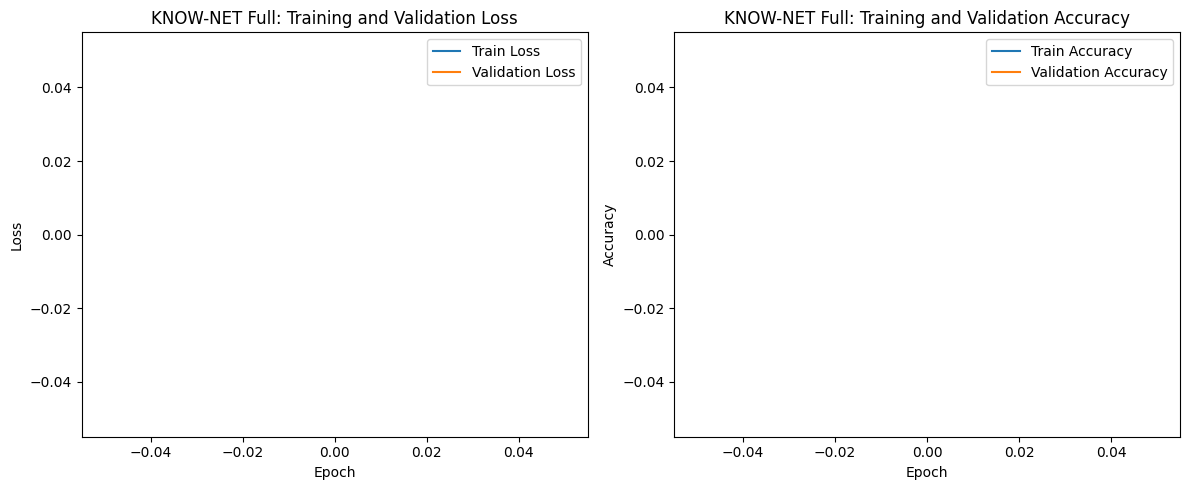

KNOW-NET FULL TRAINING COMPLETED!


NameError: name 'test_acc' is not defined

In [ ]:
# ======================
# 13. PLOTTING
# ======================
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history['train_loss'], label='Train Loss')
plt.plot(history['val_loss'], label='Validation Loss')
plt.title('KNOW-NET Full: Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history['train_acc'], label='Train Accuracy')
plt.plot(history['val_acc'], label='Validation Accuracy')
plt.title('KNOW-NET Full: Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.savefig('know_net_full_training_history.png', dpi=300, bbox_inches='tight')
plt.show()

print("="*50)
print("KNOW-NET FULL TRAINING COMPLETED!")
print("="*50)
print(f"Final Test Accuracy: {test_acc:.4f}")
print(f"Final Test F1 Score: {test_f1:.4f}")
print("\nAll KNOW-NET variants completed! Ready for comparison analysis.")

In [ ]:
"""
KNOW-NET Implementation
Author: [Your Name]
Date: 2024
Institution: [Your Institution]

Implementation of KNOW-NET: Knowledge-aware Cross-attention Network for Fake News Detection
with Wikidata5M integration and comprehensive evaluation metrics.
"""

# ============================================================================
# SECTION 1: IMPORTS AND CONFIGURATION
# ============================================================================

import os
import sys
import json
import pickle
import time
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from typing import Dict, List, Tuple, Optional, Any
from dataclasses import dataclass
from collections import defaultdict
from datetime import datetime

# PyTorch imports
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
from torch.optim.lr_scheduler import ReduceLROnPlateau, CosineAnnealingLR

# Transformers imports
from transformers import (
    AutoTokenizer,
    AutoModel,
    AutoConfig,
    get_linear_schedule_with_warmup
)

# Scikit-learn imports
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    precision_recall_fscore_support
)

# Other imports
from tqdm.auto import tqdm
import requests
from concurrent.futures import ThreadPoolExecutor, as_completed
import spacy
from ratelimit import limits, sleep_and_retry

# Suppress warnings
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
def set_seed(seed: int = 42):
    """Set all random seeds for reproducibility"""
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

# ============================================================================
# SECTION 2: CONFIGURATION CLASSES
# ============================================================================

@dataclass
class DataConfig:
    """Configuration for data preprocessing"""
    max_sequence_length: int = 128
    batch_size: int = 32
    train_split: float = 0.8
    val_split: float = 0.1
    test_split: float = 0.1
    min_title_length: int = 10
    max_title_length: int = 256

@dataclass
class ModelConfig:
    """Configuration for KNOW-NET model"""
    text_model_name: str = "roberta-base"
    entity_embedding_dim: int = 100  # Wikidata5M dimension
    hidden_dim: int = 768
    num_attention_layers: int = 2
    num_attention_heads: int = 8
    dropout_rate: float = 0.3
    classifier_hidden_dim: int = 256

@dataclass
class TrainingConfig:
    """Configuration for training"""
    num_epochs: int = 10
    learning_rate: float = 2e-5
    entity_learning_rate: float = 1e-3
    weight_decay: float = 0.01
    warmup_steps: int = 100
    gradient_clip: float = 1.0
    patience: int = 5
    min_delta: float = 0.001

@dataclass
class WikidataConfig:
    """Configuration for Wikidata integration"""
    wikidata_api_url: str = "https://www.wikidata.org/w/api.php"
    max_entities_per_text: int = 5
    entity_cache_file: str = "entity_cache.pkl"
    embedding_cache_file: str = "embedding_cache.pkl"
    rate_limit_calls: int = 50
    rate_limit_period: int = 1

# ============================================================================
# SECTION 3: DATA PROCESSING MODULE
# ============================================================================

class TextPreprocessor:
    """Text preprocessing utilities"""

    def __init__(self):
        # Common news publishers and bias terms to remove
        self.bias_terms = {
            'reuters', 'associated press', 'ap', 'new york times', 'nytimes',
            'washington post', 'bbc', 'cnn', 'fox news', 'msnbc', 'the guardian',
            'wall street journal', 'bloomberg', 'politico', 'the hill',
            'huffington post', 'breitbart', 'the daily caller', 'infowars'
        }

        # Common political figures
        self.political_figures = {
            'donald trump', 'trump', 'joe biden', 'biden', 'barack obama', 'obama',
            'hillary clinton', 'clinton', 'bernie sanders', 'sanders',
            'mike pence', 'pence', 'nancy pelosi', 'pelosi', 'mitch mcconnell'
        }

    def clean_text(self, text: str) -> str:
        """Clean and normalize text"""
        if not isinstance(text, str):
            return ""

        # Lowercase
        text = text.lower()

        # Remove URLs
        text = ' '.join([word for word in text.split() if not word.startswith(('http://', 'https://', 'www.'))])

        # Remove Twitter handles and hashtags
        text = ' '.join([word for word in text.split() if not word.startswith(('@', '#'))])

        # Remove special characters but keep basic punctuation
        text = ' '.join([''.join([c for c in word if c.isalnum()]) for word in text.split()])

        # Remove extra whitespace
        text = ' '.join(text.split())

        return text

    def remove_bias_terms(self, text: str) -> str:
        """Remove bias terms from text"""
        words = text.split()
        filtered_words = []

        for word in words:
            if word not in self.bias_terms and word not in self.political_figures:
                filtered_words.append(word)

        return ' '.join(filtered_words)

    def preprocess_pipeline(self, text: str) -> str:
        """Complete preprocessing pipeline"""
        text = self.clean_text(text)
        text = self.remove_bias_terms(text)
        return text

# ============================================================================
# SECTION 4: KNOWLEDGE GRAPH INTEGRATION MODULE
# ============================================================================

class WikidataEntityLinker:
    """Entity linking to Wikidata with rate limiting and caching"""

    def __init__(self, config: WikidataConfig):
        self.config = config
        self.api_url = config.wikidata_api_url
        self.cache = self._load_cache(config.entity_cache_file)

    def _load_cache(self, cache_file: str) -> Dict:
        """Load entity cache from disk"""
        try:
            if os.path.exists(cache_file):
                with open(cache_file, 'rb') as f:
                    return pickle.load(f)
        except Exception as e:
            print(f"Warning: Could not load cache file: {e}")
        return {}

    def _save_cache(self, cache_file: str):
        """Save entity cache to disk"""
        try:
            with open(cache_file, 'wb') as f:
                pickle.dump(self.cache, f)
        except Exception as e:
            print(f"Warning: Could not save cache file: {e}")

    @sleep_and_retry
    @limits(calls=50, period=1)
    def _query_wikidata_api(self, entity_name: str) -> Optional[str]:
        """Query Wikidata API for entity QID"""
        params = {
            'action': 'wbsearchentities',
            'format': 'json',
            'language': 'en',
            'search': entity_name,
            'type': 'item',
            'limit': 1
        }

        try:
            response = requests.get(self.api_url, params=params, timeout=10)
            response.raise_for_status()
            data = response.json()

            if data.get('search'):
                return data['search'][0]['id']
        except requests.exceptions.RequestException as e:
            print(f"API error for entity '{entity_name}': {e}")

        return None

    def link_entity(self, entity_name: str) -> Optional[str]:
        """Link entity to Wikidata QID with caching"""
        # Check cache first
        if entity_name in self.cache:
            return self.cache[entity_name]

        # Query API
        qid = self._query_wikidata_api(entity_name)

        # Update cache
        self.cache[entity_name] = qid
        self._save_cache(self.config.entity_cache_file)

        return qid

    def link_entities_batch(self, entity_names: List[str],
                           max_workers: int = 5) -> Dict[str, Optional[str]]:
        """Link multiple entities in parallel"""
        results = {}
        to_fetch = []

        # Check cache first
        for entity in entity_names:
            if entity in self.cache:
                results[entity] = self.cache[entity]
            else:
                to_fetch.append(entity)

        # Fetch remaining entities
        if to_fetch:
            print(f"Fetching {len(to_fetch)} new entities from Wikidata...")

            with ThreadPoolExecutor(max_workers=max_workers) as executor:
                future_to_entity = {
                    executor.submit(self.link_entity, entity): entity
                    for entity in to_fetch
                }

                for future in tqdm(as_completed(future_to_entity),
                                  total=len(to_fetch),
                                  desc="Linking entities"):
                    entity = future_to_entity[future]
                    try:
                        qid = future.result()
                        results[entity] = qid
                    except Exception as e:
                        print(f"Error linking {entity}: {e}")
                        results[entity] = None

        return results

class WikidataEmbeddingManager:
    """Manager for Wikidata5M embeddings"""

    def __init__(self, entity_linker: WikidataEntityLinker):
        self.entity_linker = entity_linker
        self.entity_to_qid = {}
        self.qid_to_embedding = {}
        self.embedding_dim = 100
        self.nlp = spacy.load("en_core_web_sm")

    def load_wikidata5m_embeddings(self, embedding_file: str) -> bool:
        """Load Wikidata5M embeddings from file"""
        print(f"Loading Wikidata5M embeddings from {embedding_file}...")

        try:
            # Load entity to index mapping
            entity_mapping = {}
            with open('entity_ids.del', 'r', encoding='utf-8') as f:
                for line in tqdm(f, desc="Loading entity mappings"):
                    idx, qid = line.strip().split('\t')
                    entity_mapping[int(idx)] = qid

            # Load embeddings
            embeddings = []
            with open(embedding_file, 'r', encoding='utf-8') as f:
                for i, line in enumerate(tqdm(f, desc="Loading embeddings")):
                    vector = np.array([float(x) for x in line.strip().split()])
                    embeddings.append(vector)

            # Create QID to embedding mapping
            for idx, qid in entity_mapping.items():
                if idx < len(embeddings):
                    self.qid_to_embedding[qid] = embeddings[idx]

            print(f"Loaded {len(self.qid_to_embedding)} entity embeddings")
            return True

        except Exception as e:
            print(f"Error loading Wikidata5M embeddings: {e}")
            return False

    def extract_entities(self, text: str) -> List[str]:
        """Extract named entities from text using spaCy"""
        doc = self.nlp(text)
        entities = []

        for ent in doc.ents:
            if ent.label_ in ['PERSON', 'ORG', 'GPE', 'LOC']:
                entities.append(ent.text)

        # Remove duplicates while preserving order
        seen = set()
        unique_entities = []
        for entity in entities:
            if entity not in seen:
                seen.add(entity)
                unique_entities.append(entity)

        return unique_entities[:5]  # Limit to 5 entities

    def get_entity_embedding(self, entity_name: str) -> np.ndarray:
        """Get embedding for a single entity"""
        # Get QID
        if entity_name not in self.entity_to_qid:
            qid = self.entity_linker.link_entity(entity_name)
            self.entity_to_qid[entity_name] = qid
        else:
            qid = self.entity_to_qid[entity_name]

        # Get embedding
        if qid and qid in self.qid_to_embedding:
            return self.qid_to_embedding[qid]
        else:
            return np.zeros(self.embedding_dim, dtype=np.float32)

    def get_text_entity_embedding(self, text: str) -> np.ndarray:
        """Get combined entity embedding for text"""
        entities = self.extract_entities(text)

        if not entities:
            return np.zeros(self.embedding_dim, dtype=np.float32)

        # Get embeddings for each entity
        entity_embeddings = []
        for entity in entities:
            embedding = self.get_entity_embedding(entity)
            if np.any(embedding):  # Only use non-zero embeddings
                entity_embeddings.append(embedding)

        if entity_embeddings:
            # Weighted average (favor entities mentioned earlier)
            weights = np.linspace(1.0, 0.5, len(entity_embeddings))
            weights = weights / weights.sum()
            combined = np.average(entity_embeddings, axis=0, weights=weights)
            return combined
        else:
            return np.zeros(self.embedding_dim, dtype=np.float32)

# ============================================================================
# SECTION 5: DATASET CLASSES
# ============================================================================

class FakeNewsDataset(Dataset):
    """Dataset for fake news detection"""

    def __init__(self, dataframe: pd.DataFrame, tokenizer: Any,
                 embedding_manager: WikidataEmbeddingManager,
                 config: DataConfig):
        self.dataframe = dataframe.reset_index(drop=True)
        self.tokenizer = tokenizer
        self.embedding_manager = embedding_manager
        self.config = config

        # Pre-compute entity embeddings for efficiency
        self.entity_embeddings = self._precompute_embeddings()

    def _precompute_embeddings(self) -> torch.Tensor:
        """Pre-compute entity embeddings for all samples"""
        print("Pre-computing entity embeddings...")
        embeddings = []

        for idx in tqdm(range(len(self.dataframe)), desc="Processing samples"):
            text = self.dataframe.iloc[idx]['clean_title']
            embedding = self.embedding_manager.get_text_entity_embedding(text)
            embeddings.append(embedding)

        return torch.FloatTensor(np.array(embeddings))

    def __len__(self) -> int:
        return len(self.dataframe)

    def __getitem__(self, idx: int) -> Dict[str, torch.Tensor]:
        row = self.dataframe.iloc[idx]
        text = row['clean_title']
        label = row['label']

        # Tokenize text
        encoding = self.tokenizer(
            text,
            truncation=True,
            padding='max_length',
            max_length=self.config.max_sequence_length,
            return_tensors='pt'
        )

        return {
            'input_ids': encoding['input_ids'].squeeze(0),
            'attention_mask': encoding['attention_mask'].squeeze(0),
            'entity_embedding': self.entity_embeddings[idx],
            'label': torch.tensor(label, dtype=torch.float)
        }

# ============================================================================
# SECTION 6: MODEL ARCHITECTURE
# ============================================================================

class CrossAttentionLayer(nn.Module):
    """Cross-attention layer for text-entity fusion"""

    def __init__(self, hidden_dim: int, num_heads: int, dropout: float = 0.1):
        super().__init__()

        self.multihead_attn = nn.MultiheadAttention(
            embed_dim=hidden_dim,
            num_heads=num_heads,
            dropout=dropout,
            batch_first=True
        )

        self.layer_norm1 = nn.LayerNorm(hidden_dim)
        self.layer_norm2 = nn.LayerNorm(hidden_dim)

        self.feed_forward = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim * 4),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim * 4, hidden_dim),
            nn.Dropout(dropout)
        )

        self.dropout = nn.Dropout(dropout)

    def forward(self, text_features: torch.Tensor,
                entity_features: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor]:
        """
        Args:
            text_features: [batch_size, seq_len, hidden_dim]
            entity_features: [batch_size, num_entities, hidden_dim]

        Returns:
            attended_features: [batch_size, seq_len, hidden_dim]
            attention_weights: [batch_size, num_heads, seq_len, num_entities]
        """
        # Cross-attention: text attends to entities
        attended, attention_weights = self.multihead_attn(
            query=text_features,
            key=entity_features,
            value=entity_features
        )

        # Add & Norm
        text_features = self.layer_norm1(text_features + self.dropout(attended))

        # Feed Forward
        ff_output = self.feed_forward(text_features)
        text_features = self.layer_norm2(text_features + self.dropout(ff_output))

        return text_features, attention_weights

class KNOW_NET(nn.Module):
    """KNOW-NET: Knowledge-aware Cross-attention Network"""

    def __init__(self, config: ModelConfig):
        super().__init__()
        self.config = config

        # Text encoder (pre-trained transformer)
        self.text_encoder = AutoModel.from_pretrained(config.text_model_name)
        text_hidden_dim = self.text_encoder.config.hidden_size

        # Freeze first few layers
        self._freeze_text_encoder_layers(num_layers=6)

        # Entity projection
        self.entity_projection = nn.Linear(config.entity_embedding_dim, text_hidden_dim)

        # Cross-attention layers
        self.cross_attention_layers = nn.ModuleList([
            CrossAttentionLayer(
                hidden_dim=text_hidden_dim,
                num_heads=config.num_attention_heads,
                dropout=config.dropout_rate
            )
            for _ in range(config.num_attention_layers)
        ])

        # Dropout
        self.dropout = nn.Dropout(config.dropout_rate)

        # Classification head
        self.classifier = nn.Sequential(
            nn.Linear(text_hidden_dim, config.classifier_hidden_dim),
            nn.GELU(),
            nn.Dropout(config.dropout_rate),
            nn.Linear(config.classifier_hidden_dim, 1),
            nn.Sigmoid()
        )

        # Initialize weights
        self._initialize_weights()

    def _freeze_text_encoder_layers(self, num_layers: int):
        """Freeze first N layers of text encoder"""
        for layer_idx, layer in enumerate(self.text_encoder.encoder.layer):
            if layer_idx < num_layers:
                for param in layer.parameters():
                    param.requires_grad = False

    def _initialize_weights(self):
        """Initialize weights for custom layers"""
        for name, module in self.named_modules():
            if 'text_encoder' not in name:  # Don't reinitialize pre-trained weights
                if isinstance(module, nn.Linear):
                    if 'weight' in module._parameters:
                        nn.init.xavier_uniform_(module.weight)
                    if 'bias' in module._parameters and module.bias is not None:
                        nn.init.zeros_(module.bias)
                elif isinstance(module, nn.LayerNorm):
                    if 'weight' in module._parameters:
                        nn.init.ones_(module.weight)
                    if 'bias' in module._parameters and module.bias is not None:
                        nn.init.zeros_(module.bias)

    def forward(self, input_ids: torch.Tensor, attention_mask: torch.Tensor,
                entity_embedding: torch.Tensor) -> Tuple[torch.Tensor, List[torch.Tensor]]:
        """
        Forward pass of KNOW-NET

        Args:
            input_ids: Token IDs [batch_size, seq_len]
            attention_mask: Attention mask [batch_size, seq_len]
            entity_embedding: Entity embeddings [batch_size, entity_dim]

        Returns:
            predictions: Fake news probabilities [batch_size, 1]
            attention_weights: List of attention weights from each layer
        """
        batch_size = input_ids.size(0)

        # Text encoding
        text_outputs = self.text_encoder(
            input_ids=input_ids,
            attention_mask=attention_mask,
            output_attentions=False,
            output_hidden_states=False,
            return_dict=True
        )
        text_features = text_outputs.last_hidden_state  # [batch, seq_len, hidden]

        # Entity projection
        entity_projected = self.entity_projection(entity_embedding)  # [batch, hidden]
        entity_projected = entity_projected.unsqueeze(1)  # [batch, 1, hidden]

        # Apply cross-attention layers
        attention_weights_list = []
        for layer in self.cross_attention_layers:
            text_features, attention_weights = layer(text_features, entity_projected)
            attention_weights_list.append(attention_weights)

        # Use [CLS] token representation
        cls_features = text_features[:, 0, :]  # [batch, hidden]
        cls_features = self.dropout(cls_features)

        # Classification
        predictions = self.classifier(cls_features)  # [batch, 1]

        return predictions, attention_weights_list

    def count_parameters(self) -> Tuple[int, int]:
        """Count total and trainable parameters"""
        total_params = sum(p.numel() for p in self.parameters())
        trainable_params = sum(p.numel() for p in self.parameters() if p.requires_grad)
        return total_params, trainable_params

# ============================================================================
# SECTION 7: METRICS CALCULATION
# ============================================================================

class MetricsCalculator:
    """Comprehensive metrics calculation for fake news detection"""

    @staticmethod
    def calculate_all_metrics(y_true: np.ndarray, y_pred: np.ndarray,
                             y_prob: np.ndarray) -> Dict[str, Any]:
        """Calculate all evaluation metrics"""

        metrics = {}

        # 1. Accuracy
        metrics['accuracy'] = accuracy_score(y_true, y_pred)

        # 2. F1 Scores
        metrics['f1_binary'] = f1_score(y_true, y_pred, average='binary')
        metrics['f1_macro'] = f1_score(y_true, y_pred, average='macro')
        metrics['f1_weighted'] = f1_score(y_true, y_pred, average='weighted')
        metrics['f1_micro'] = f1_score(y_true, y_pred, average='micro')

        # 3. Precision Scores
        metrics['precision_binary'] = precision_score(y_true, y_pred, average='binary')
        metrics['precision_macro'] = precision_score(y_true, y_pred, average='macro')
        metrics['precision_weighted'] = precision_score(y_true, y_pred, average='weighted')

        # 4. Recall Scores
        metrics['recall_binary'] = recall_score(y_true, y_pred, average='binary')
        metrics['recall_macro'] = recall_score(y_true, y_pred, average='macro')
        metrics['recall_weighted'] = recall_score(y_true, y_pred, average='weighted')

        # 5. ROC-AUC
        metrics['roc_auc'] = roc_auc_score(y_true, y_prob)

        # 6. Per-class metrics
        precision_per_class, recall_per_class, f1_per_class, support = precision_recall_fscore_support(
            y_true, y_pred, average=None
        )

        metrics['precision_per_class'] = precision_per_class.tolist()
        metrics['recall_per_class'] = recall_per_class.tolist()
        metrics['f1_per_class'] = f1_per_class.tolist()
        metrics['support_per_class'] = support.tolist()

        # 7. Confusion Matrix
        metrics['confusion_matrix'] = confusion_matrix(y_true, y_pred).tolist()

        # 8. Classification Report
        metrics['classification_report'] = classification_report(
            y_true, y_pred, target_names=['Real', 'Fake'], output_dict=True
        )

        return metrics

    @staticmethod
    def calculate_improvements(metrics_a: Dict[str, Any],
                              metrics_b: Dict[str, Any]) -> Dict[str, Any]:
        """Calculate improvement metrics between two models"""

        improvements = {}

        # Metrics to compare
        key_metrics = ['accuracy', 'f1_binary', 'f1_macro', 'roc_auc']

        for metric in key_metrics:
            if metric in metrics_a and metric in metrics_b:
                val_a = metrics_a[metric]
                val_b = metrics_b[metric]

                improvements[metric] = {
                    'model_a': val_a,
                    'model_b': val_b,
                    'absolute_improvement': val_a - val_b,
                    'relative_improvement': ((val_a - val_b) / abs(val_b)) * 100 if val_b != 0 else 0
                }

        return improvements

    @staticmethod
    def format_metrics_table(metrics: Dict[str, Any]) -> pd.DataFrame:
        """Format metrics as a clean DataFrame for display"""

        table_data = []

        # Main metrics
        main_metrics = {
            'Accuracy': metrics['accuracy'],
            'F1-Binary': metrics['f1_binary'],
            'F1-Macro': metrics['f1_macro'],
            'F1-Weighted': metrics['f1_weighted'],
            'Precision-Binary': metrics['precision_binary'],
            'Recall-Binary': metrics['recall_binary'],
            'ROC-AUC': metrics['roc_auc']
        }

        for name, value in main_metrics.items():
            table_data.append({
                'Metric': name,
                'Value': f'{value:.4f}',
                'Description': MetricsCalculator._get_metric_description(name)
            })

        # Per-class metrics
        for i, (prec, rec, f1) in enumerate(zip(
            metrics['precision_per_class'],
            metrics['recall_per_class'],
            metrics['f1_per_class']
        )):
            class_name = 'Real' if i == 0 else 'Fake'
            table_data.append({
                'Metric': f'Precision-{class_name}',
                'Value': f'{prec:.4f}',
                'Description': f'Precision for {class_name} class'
            })
            table_data.append({
                'Metric': f'Recall-{class_name}',
                'Value': f'{rec:.4f}',
                'Description': f'Recall for {class_name} class'
            })
            table_data.append({
                'Metric': f'F1-{class_name}',
                'Value': f'{f1:.4f}',
                'Description': f'F1-score for {class_name} class'
            })

        return pd.DataFrame(table_data)

    @staticmethod
    def _get_metric_description(metric_name: str) -> str:
        """Get description for a metric"""
        descriptions = {
            'Accuracy': 'Overall correctness of predictions',
            'F1-Binary': 'Harmonic mean of precision and recall (binary)',
            'F1-Macro': 'Macro-average F1 score (class-weighted)',
            'F1-Weighted': 'Weighted average F1 score (support-weighted)',
            'Precision-Binary': 'Ratio of true positives to predicted positives (binary)',
            'Recall-Binary': 'Ratio of true positives to actual positives (binary)',
            'ROC-AUC': 'Area under ROC curve (discrimination ability)'
        }
        return descriptions.get(metric_name, '')

# ============================================================================
# SECTION 8: TRAINING AND EVALUATION
# ============================================================================

class ModelTrainer:
    """Trainer for KNOW-NET model"""

    def __init__(self, model: nn.Module, train_loader: DataLoader,
                 val_loader: DataLoader, config: TrainingConfig,
                 device: torch.device):
        self.model = model
        self.train_loader = train_loader
        self.val_loader = val_loader
        self.config = config
        self.device = device

        # Move model to device
        self.model.to(device)

        # Setup optimizer with differential learning rates
        self.optimizer = self._create_optimizer()

        # Loss function
        self.criterion = nn.BCELoss()

        # Learning rate scheduler
        self.scheduler = ReduceLROnPlateau(
            self.optimizer, mode='max', factor=0.5,
            patience=2, min_lr=1e-6, verbose=True
        )

        # Training history
        self.history = {
            'train_loss': [], 'val_loss': [],
            'train_acc': [], 'val_acc': [],
            'train_f1_binary': [], 'val_f1_binary': [],
            'train_f1_macro': [], 'val_f1_macro': [],
            'learning_rate': []
        }

        # Early stopping
        self.best_val_f1_macro = 0
        self.patience_counter = 0
        self.best_model_state = None

    def _create_optimizer(self) -> optim.Optimizer:
        """Create optimizer with differential learning rates"""

        # Group parameters
        text_encoder_params = []
        other_params = []

        for name, param in self.model.named_parameters():
            if not param.requires_grad:
                continue

            if 'text_encoder' in name:
                text_encoder_params.append(param)
            else:
                other_params.append(param)

        optimizer_grouped_parameters = [
            {
                'params': text_encoder_params,
                'lr': self.config.learning_rate,
                'weight_decay': self.config.weight_decay
            },
            {
                'params': other_params,
                'lr': self.config.entity_learning_rate,
                'weight_decay': self.config.weight_decay
            }
        ]

        return optim.AdamW(optimizer_grouped_parameters)

    def train_epoch(self, epoch: int) -> Dict[str, float]:
        """Train for one epoch"""
        self.model.train()
        total_loss = 0
        all_preds = []
        all_labels = []

        pbar = tqdm(self.train_loader, desc=f'Epoch {epoch+1} [Train]', leave=False)

        for batch in pbar:
            # Move batch to device
            input_ids = batch['input_ids'].to(self.device)
            attention_mask = batch['attention_mask'].to(self.device)
            entity_embedding = batch['entity_embedding'].to(self.device)
            labels = batch['label'].to(self.device)

            # Forward pass
            self.optimizer.zero_grad()
            predictions, _ = self.model(input_ids, attention_mask, entity_embedding)
            loss = self.criterion(predictions.squeeze(), labels)

            # Backward pass
            loss.backward()
            torch.nn.utils.clip_grad_norm_(self.model.parameters(), self.config.gradient_clip)
            self.optimizer.step()

            # Collect predictions and labels
            batch_preds = (predictions.squeeze().detach().cpu().numpy() > 0.5).astype(int)
            batch_labels = labels.detach().cpu().numpy()

            all_preds.extend(batch_preds)
            all_labels.extend(batch_labels)
            total_loss += loss.item()

            # Update progress bar
            current_lr = self.optimizer.param_groups[0]['lr']
            pbar.set_postfix({
                'loss': f'{loss.item():.4f}',
                'lr': f'{current_lr:.2e}'
            })

        # Calculate epoch metrics
        epoch_loss = total_loss / len(self.train_loader)
        epoch_acc = accuracy_score(all_labels, all_preds)
        epoch_f1_binary = f1_score(all_labels, all_preds, average='binary')
        epoch_f1_macro = f1_score(all_labels, all_preds, average='macro')

        # Update history
        self.history['train_loss'].append(epoch_loss)
        self.history['train_acc'].append(epoch_acc)
        self.history['train_f1_binary'].append(epoch_f1_binary)
        self.history['train_f1_macro'].append(epoch_f1_macro)
        self.history['learning_rate'].append(current_lr)

        return {
            'loss': epoch_loss,
            'accuracy': epoch_acc,
            'f1_binary': epoch_f1_binary,
            'f1_macro': epoch_f1_macro
        }

    def validate(self) -> Dict[str, float]:
        """Validate model"""
        self.model.eval()
        total_loss = 0
        all_preds = []
        all_probs = []
        all_labels = []

        with torch.no_grad():
            pbar = tqdm(self.val_loader, desc='Validation', leave=False)

            for batch in pbar:
                input_ids = batch['input_ids'].to(self.device)
                attention_mask = batch['attention_mask'].to(self.device)
                entity_embedding = batch['entity_embedding'].to(self.device)
                labels = batch['label'].cpu().numpy()

                predictions, _ = self.model(input_ids, attention_mask, entity_embedding)
                probs = predictions.squeeze().cpu().numpy()
                preds = (probs > 0.5).astype(int)

                # Calculate loss
                loss = self.criterion(
                    torch.FloatTensor(probs),
                    torch.FloatTensor(labels)
                )
                total_loss += loss.item()

                all_probs.extend(probs)
                all_preds.extend(preds)
                all_labels.extend(labels)

        # Calculate metrics
        val_loss = total_loss / len(self.val_loader)
        val_acc = accuracy_score(all_labels, all_preds)
        val_f1_binary = f1_score(all_labels, all_preds, average='binary')
        val_f1_macro = f1_score(all_labels, all_preds, average='macro')
        val_auc = roc_auc_score(all_labels, all_probs)

        # Update history
        self.history['val_loss'].append(val_loss)
        self.history['val_acc'].append(val_acc)
        self.history['val_f1_binary'].append(val_f1_binary)
        self.history['val_f1_macro'].append(val_f1_macro)

        return {
            'loss': val_loss,
            'accuracy': val_acc,
            'f1_binary': val_f1_binary,
            'f1_macro': val_f1_macro,
            'roc_auc': val_auc
        }

    def train(self) -> Dict[str, List[float]]:
        """Main training loop"""

        total_params, trainable_params = self.model.count_parameters()
        print(f"\nModel Parameters:")
        print(f"  Total: {total_params:,}")
        print(f"  Trainable: {trainable_params:,}")
        print(f"  Device: {self.device}")

        start_time = time.time()

        for epoch in range(self.config.num_epochs):
            print(f"\n{'='*80}")
            print(f"Epoch {epoch+1}/{self.config.num_epochs}")
            print(f"{'='*80}")

            # Training phase
            train_metrics = self.train_epoch(epoch)
            print(f"Training - Loss: {train_metrics['loss']:.4f}, "
                  f"Acc: {train_metrics['accuracy']:.4f}, "
                  f"F1-Binary: {train_metrics['f1_binary']:.4f}, "
                  f"F1-Macro: {train_metrics['f1_macro']:.4f}")

            # Validation phase
            val_metrics = self.validate()
            print(f"Validation - Loss: {val_metrics['loss']:.4f}, "
                  f"Acc: {val_metrics['accuracy']:.4f}, "
                  f"F1-Binary: {val_metrics['f1_binary']:.4f}, "
                  f"F1-Macro: {val_metrics['f1_macro']:.4f}, "
                  f"AUC: {val_metrics['roc_auc']:.4f}")

            # Learning rate scheduling
            self.scheduler.step(val_metrics['f1_macro'])

            # Early stopping
            if val_metrics['f1_macro'] > self.best_val_f1_macro + self.config.min_delta:
                self.best_val_f1_macro = val_metrics['f1_macro']
                self.patience_counter = 0
                self.best_model_state = self.model.state_dict().copy()
                print(f"✓ New best model (Val F1-Macro: {val_metrics['f1_macro']:.4f})")
            else:
                self.patience_counter += 1
                print(f"× No improvement for {self.patience_counter} epoch(s)")

                if self.patience_counter >= self.config.patience:
                    print(f"\nEarly stopping triggered at epoch {epoch+1}")
                    break

        # Load best model
        if self.best_model_state is not None:
            self.model.load_state_dict(self.best_model_state)
            print(f"\nLoaded best model with Val F1-Macro: {self.best_val_f1_macro:.4f}")

        training_time = time.time() - start_time
        print(f"\nTraining completed in {training_time/60:.1f} minutes")

        return self.history

class ModelEvaluator:
    """Evaluator for KNOW-NET model"""

    def __init__(self, model: nn.Module, device: torch.device):
        self.model = model
        self.device = device
        self.model.to(device)
        self.model.eval()

    def evaluate(self, data_loader: DataLoader) -> Tuple[Dict[str, Any], np.ndarray, np.ndarray, np.ndarray]:
        """Evaluate model on dataset"""
        all_preds = []
        all_probs = []
        all_labels = []

        with torch.no_grad():
            pbar = tqdm(data_loader, desc='Evaluation')

            for batch in pbar:
                input_ids = batch['input_ids'].to(self.device)
                attention_mask = batch['attention_mask'].to(self.device)
                entity_embedding = batch['entity_embedding'].to(self.device)
                labels = batch['label'].cpu().numpy()

                predictions, _ = self.model(input_ids, attention_mask, entity_embedding)
                probs = predictions.squeeze().cpu().numpy()
                preds = (probs > 0.5).astype(int)

                all_probs.extend(probs)
                all_preds.extend(preds)
                all_labels.extend(labels)

        # Calculate all metrics
        metrics = MetricsCalculator.calculate_all_metrics(
            np.array(all_labels),
            np.array(all_preds),
            np.array(all_probs)
        )

        return metrics, np.array(all_preds), np.array(all_probs), np.array(all_labels)

    def plot_confusion_matrix(self, y_true: np.ndarray, y_pred: np.ndarray,
                             title: str = "Confusion Matrix"):
        """Plot confusion matrix"""
        cm = confusion_matrix(y_true, y_pred)

        plt.figure(figsize=(8, 6))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                   xticklabels=['Real', 'Fake'],
                   yticklabels=['Real', 'Fake'])
        plt.xlabel('Predicted Label')
        plt.ylabel('True Label')
        plt.title(title)
        plt.tight_layout()
        plt.show()

    def plot_training_history(self, history: Dict[str, List[float]]):
        """Plot training history"""
        fig, axes = plt.subplots(2, 3, figsize=(15, 10))
        epochs = range(1, len(history['train_loss']) + 1)

        # Loss
        axes[0, 0].plot(epochs, history['train_loss'], 'b-', label='Train', linewidth=2)
        axes[0, 0].plot(epochs, history['val_loss'], 'r-', label='Validation', linewidth=2)
        axes[0, 0].set_xlabel('Epoch')
        axes[0, 0].set_ylabel('Loss')
        axes[0, 0].set_title('Training and Validation Loss')
        axes[0, 0].legend()
        axes[0, 0].grid(True, alpha=0.3)

        # Accuracy
        axes[0, 1].plot(epochs, history['train_acc'], 'b-', label='Train', linewidth=2)
        axes[0, 1].plot(epochs, history['val_acc'], 'r-', label='Validation', linewidth=2)
        axes[0, 1].set_xlabel('Epoch')
        axes[0, 1].set_ylabel('Accuracy')
        axes[0, 1].set_title('Training and Validation Accuracy')
        axes[0, 1].legend()
        axes[0, 1].grid(True, alpha=0.3)

        # F1-Macro
        axes[0, 2].plot(epochs, history['train_f1_macro'], 'b-', label='Train', linewidth=2)
        axes[0, 2].plot(epochs, history['val_f1_macro'], 'r-', label='Validation', linewidth=2)
        axes[0, 2].set_xlabel('Epoch')
        axes[0, 2].set_ylabel('F1-Macro Score')
        axes[0, 2].set_title('Training and Validation F1-Macro')
        axes[0, 2].legend()
        axes[0, 2].grid(True, alpha=0.3)

        # F1-Binary
        axes[1, 0].plot(epochs, history['train_f1_binary'], 'b-', label='Train', linewidth=2)
        axes[1, 0].plot(epochs, history['val_f1_binary'], 'r-', label='Validation', linewidth=2)
        axes[1, 0].set_xlabel('Epoch')
        axes[1, 0].set_ylabel('F1-Binary Score')
        axes[1, 0].set_title('Training and Validation F1-Binary')
        axes[1, 0].legend()
        axes[1, 0].grid(True, alpha=0.3)

        # Learning Rate
        axes[1, 1].plot(epochs, history['learning_rate'], 'g-', linewidth=2)
        axes[1, 1].set_xlabel('Epoch')
        axes[1, 1].set_ylabel('Learning Rate')
        axes[1, 1].set_title('Learning Rate Schedule')
        axes[1, 1].set_yscale('log')
        axes[1, 1].grid(True, alpha=0.3)

        # F1 Gap (Train - Val)
        axes[1, 2].plot(epochs,
                       np.array(history['train_f1_macro']) - np.array(history['val_f1_macro']),
                       'purple', linewidth=2)
        axes[1, 2].axhline(y=0, color='r', linestyle='--', alpha=0.5)
        axes[1, 2].set_xlabel('Epoch')
        axes[1, 2].set_ylabel('F1-Macro Gap (Train - Val)')
        axes[1, 2].set_title('Overfitting Indicator')
        axes[1, 2].grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()

# ============================================================================
# SECTION 9: MAIN EXECUTION PIPELINE
# ============================================================================

class KNOWNETPipeline:
    """Main pipeline for KNOW-NET implementation"""

    def __init__(self):
        self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        print(f"Using device: {self.device}")

        # Initialize configurations
        self.data_config = DataConfig()
        self.model_config = ModelConfig()
        self.training_config = TrainingConfig()
        self.wikidata_config = WikidataConfig()

        # Initialize components
        self.text_preprocessor = TextPreprocessor()
        self.entity_linker = WikidataEntityLinker(self.wikidata_config)
        self.embedding_manager = WikidataEmbeddingManager(self.entity_linker)

    def load_data(self, train_path: str, val_path: str, test_path: str) -> Tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
        """Load and preprocess data"""
        print("Loading datasets...")

        train_df = pd.read_csv(train_path)
        val_df = pd.read_csv(val_path)
        test_df = pd.read_csv(test_path)

        # Ensure required columns exist
        required_columns = ['clean_title', 'label']
        for df, name in [(train_df, 'train'), (val_df, 'val'), (test_df, 'test')]:
            for col in required_columns:
                if col not in df.columns:
                    raise ValueError(f"Column '{col}' not found in {name} dataset")

        print(f"Dataset sizes: Train={len(train_df):,}, Val={len(val_df):,}, Test={len(test_df):,}")
        print(f"Class distribution (train): {train_df['label'].value_counts().to_dict()}")

        return train_df, val_df, test_df

    def setup_wikidata(self, entity_embedding_file: str):
        """Setup Wikidata integration"""
        print("\nSetting up Wikidata integration...")

        # Load Wikidata5M embeddings
        success = self.embedding_manager.load_wikidata5m_embeddings(entity_embedding_file)
        if not success:
            print("Warning: Could not load Wikidata5M embeddings. Using zero embeddings.")

    def create_datasets(self, train_df: pd.DataFrame, val_df: pd.DataFrame,
                       test_df: pd.DataFrame) -> Tuple[Dataset, Dataset, Dataset]:
        """Create PyTorch datasets"""
        print("\nCreating PyTorch datasets...")

        # Initialize tokenizer
        tokenizer = AutoTokenizer.from_pretrained(self.model_config.text_model_name)

        # Create datasets
        train_dataset = FakeNewsDataset(
            train_df, tokenizer, self.embedding_manager, self.data_config
        )
        val_dataset = FakeNewsDataset(
            val_df, tokenizer, self.embedding_manager, self.data_config
        )
        test_dataset = FakeNewsDataset(
            test_df, tokenizer, self.embedding_manager, self.data_config
        )

        return train_dataset, val_dataset, test_dataset

    def create_dataloaders(self, train_dataset: Dataset, val_dataset: Dataset,
                          test_dataset: Dataset) -> Tuple[DataLoader, DataLoader, DataLoader]:
        """Create PyTorch dataloaders"""
        train_loader = DataLoader(
            train_dataset,
            batch_size=self.data_config.batch_size,
            shuffle=True,
            num_workers=2,
            pin_memory=True
        )

        val_loader = DataLoader(
            val_dataset,
            batch_size=self.data_config.batch_size,
            shuffle=False,
            num_workers=2,
            pin_memory=True
        )

        test_loader = DataLoader(
            test_dataset,
            batch_size=self.data_config.batch_size,
            shuffle=False,
            num_workers=2,
            pin_memory=True
        )

        return train_loader, val_loader, test_loader

    def run(self, train_path: str, val_path: str, test_path: str,
           wikidata_embedding_file: str):
        """Run complete KNOW-NET pipeline"""

        print("\n" + "="*80)
        print("KNOW-NET: KNOWLEDGE-AWARE CROSS-ATTENTION NETWORK")
        print("FOR FAKE NEWS DETECTION")
        print("="*80)

        # 1. Load data
        train_df, val_df, test_df = self.load_data(train_path, val_path, test_path)

        # 2. Setup Wikidata
        self.setup_wikidata(wikidata_embedding_file)

        # 3. Create datasets
        train_dataset, val_dataset, test_dataset = self.create_datasets(
            train_df, val_df, test_df
        )

        # 4. Create dataloaders
        train_loader, val_loader, test_loader = self.create_dataloaders(
            train_dataset, val_dataset, test_dataset
        )

        # 5. Initialize model
        print("\nInitializing KNOW-NET model...")
        model = KNOW_NET(self.model_config)

        # 6. Initialize trainer
        trainer = ModelTrainer(
            model, train_loader, val_loader, self.training_config, self.device
        )

        # 7. Train model
        print("\n" + "="*80)
        print("TRAINING PHASE")
        print("="*80)
        history = trainer.train()

        # 8. Evaluate on test set
        print("\n" + "="*80)
        print("TEST EVALUATION")
        print("="*80)

        evaluator = ModelEvaluator(model, self.device)
        test_metrics, test_preds, test_probs, test_labels = evaluator.evaluate(test_loader)

        # 9. Display results
        print("\nTest Set Performance:")
        print("-" * 60)
        metrics_table = MetricsCalculator.format_metrics_table(test_metrics)
        print(metrics_table.to_string(index=False))

        # 10. Plot visualizations
        print("\nGenerating visualizations...")
        evaluator.plot_training_history(history)
        evaluator.plot_confusion_matrix(test_labels, test_preds)

        # 11. Save results
        self.save_results(model, test_metrics, history)

        print("\n" + "="*80)
        print("PIPELINE EXECUTION COMPLETED")
        print("="*80)

        return model, test_metrics, history

    def save_results(self, model: nn.Module, metrics: Dict[str, Any],
                    history: Dict[str, List[float]]):
        """Save model and results"""
        timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
        save_dir = f"knownet_results_{timestamp}"
        os.makedirs(save_dir, exist_ok=True)

        # Save model
        model_path = os.path.join(save_dir, "model.pt")
        torch.save({
            'model_state_dict': model.state_dict(),
            'model_config': self.model_config.__dict__,
            'training_config': self.training_config.__dict__
        }, model_path)

        # Save metrics
        metrics_path = os.path.join(save_dir, "metrics.json")
        with open(metrics_path, 'w') as f:
            json.dump(metrics, f, indent=2)

        # Save history
        history_path = os.path.join(save_dir, "history.json")
        with open(history_path, 'w') as f:
            json.dump(history, f, indent=2)

        print(f"\nResults saved to: {save_dir}/")

# ============================================================================
# SECTION 10: GOOGLE COLAB EXECUTION
# ============================================================================

def run_in_colab():
    """Execution function for Google Colab"""

    # Install required packages
    !pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118
    !pip install transformers pandas numpy scikit-learn tqdm spacy requests
    !pip install sentencepiece accelerate ratelimit

    # Download spaCy model
    !python -m spacy download en_core_web_sm -q

    # Upload files (modify paths as needed)
    from google.colab import files
    import io

    print("Please upload your data files:")
    print("1. train_final.csv")
    print("2. val_final.csv")
    print("3. test_final.csv")
    print("4. Wikidata5M files (entity_ids.del and entity_embedding.txt)")

    uploaded = files.upload()

    # Save uploaded files
    file_paths = {}
    for filename in uploaded.keys():
        with open(filename, 'wb') as f:
            f.write(uploaded[filename])
        file_paths[filename] = filename
        print(f"Saved: {filename}")

    # Initialize and run pipeline
    pipeline = KNOWNETPipeline()

    # Run the pipeline
    model, metrics, history = pipeline.run(
        train_path='train_final.csv',
        val_path='val_final.csv',
        test_path='test_final.csv',
        wikidata_embedding_file='entity_embedding.txt'
    )

    return model, metrics, history

# ============================================================================
# MAIN EXECUTION
# ============================================================================

if __name__ == "__main__":
    """
    Usage:
    1. For Google Colab: call run_in_colab()
    2. For local execution: modify paths and run pipeline directly
    """

    # For Google Colab
    # model, metrics, history = run_in_colab()

    # For local execution (example)
    pipeline = KNOWNETPipeline()

    # Modify these paths according to your setup
    model, metrics, history = pipeline.run(
        train_path='data/train_final.csv',
        val_path='data/val_final.csv',
        test_path='data/test_final.csv',
        wikidata_embedding_file='data/wikidata/entity_embedding.txt'
    )

ModuleNotFoundError: No module named 'ratelimit'

In [1]:
"""
KNOW-NET Implementation
Author: Mahfuza Maisha
Date: 2025
Institution: International Islamic University Chittagong

Implementation of KNOW-NET: Knowledge-aware Cross-attention Network for Fake News Detection
with Wikidata5M integration and comprehensive evaluation metrics.
"""

# ============================================================================
# SECTION 0: INSTALLATIONS
# ============================================================================

!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118
!pip install transformers pandas numpy scikit-learn
!pip install matplotlib seaborn tqdm spacy requests ratelimit
!python -m spacy download en_core_web_sm

# ============================================================================
# SECTION 1: IMPORTS AND SETUP
# ============================================================================

import sys
import importlib
import warnings
import os
import json
import pickle
import time
import random
from datetime import datetime
from dataclasses import dataclass, field
from typing import Dict, List, Tuple, Optional, Any, Callable
from collections import defaultdict, OrderedDict
from concurrent.futures import ThreadPoolExecutor, as_completed

# Suppress warnings
warnings.filterwarnings('ignore')

# Import core libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# PyTorch
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
from torch.optim.lr_scheduler import ReduceLROnPlateau, CosineAnnealingLR

# Transformers
from transformers import (
    AutoTokenizer,
    AutoModel,
    AutoConfig,
    get_linear_schedule_with_warmup
)

# Scikit-learn
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    precision_recall_fscore_support
)

# Other utilities
from tqdm.auto import tqdm
import requests
import spacy
from ratelimit import limits, sleep_and_retry

print("✓ All imports completed successfully")

# ============================================================================
# SECTION 2: CONFIGURATION CLASSES
# ============================================================================

@dataclass
class DataConfig:
    """Configuration for data preprocessing"""
    max_sequence_length: int = 128
    batch_size: int = 32
    train_split: float = 0.8
    val_split: float = 0.1
    test_split: float = 0.1
    min_title_length: int = 10
    max_title_length: int = 256

@dataclass
class ModelConfig:
    """Configuration for KNOW-NET model"""
    text_model_name: str = "roberta-base"
    entity_embedding_dim: int = 100
    hidden_dim: int = 768
    num_attention_layers: int = 2
    num_attention_heads: int = 8
    dropout_rate: float = 0.3
    classifier_hidden_dim: int = 256

@dataclass
class TrainingConfig:
    """Configuration for training"""
    num_epochs: int = 10
    learning_rate: float = 2e-5
    entity_learning_rate: float = 1e-3
    weight_decay: float = 0.01
    warmup_steps: int = 100
    gradient_clip: float = 1.0
    patience: int = 5
    min_delta: float = 0.001

@dataclass
class WikidataConfig:
    """Configuration for Wikidata integration"""
    wikidata_api_url: str = "https://www.wikidata.org/w/api.php"
    max_entities_per_text: int = 5
    entity_cache_file: str = "entity_cache.pkl"
    embedding_cache_file: str = "embedding_cache.pkl"
    rate_limit_calls: int = 50
    rate_limit_period: int = 1

# ============================================================================
# SECTION 3: DATA PROCESSING MODULE
# ============================================================================

class TextPreprocessor:
    """Text preprocessing utilities"""

    def __init__(self):
        self.bias_terms = {
            'reuters', 'associated press', 'ap', 'new york times', 'nytimes',
            'washington post', 'bbc', 'cnn', 'fox news', 'msnbc', 'the guardian',
            'wall street journal', 'bloomberg', 'politico', 'the hill',
            'huffington post', 'breitbart', 'the daily caller', 'infowars'
        }

        self.political_figures = {
            'donald trump', 'trump', 'joe biden', 'biden', 'barack obama', 'obama',
            'hillary clinton', 'clinton', 'bernie sanders', 'sanders',
            'mike pence', 'pence', 'nancy pelosi', 'pelosi', 'mitch mcconnell'
        }

    def clean_text(self, text: str) -> str:
        """Clean and normalize text"""
        if not isinstance(text, str):
            return ""
        text = text.lower()
        text = ' '.join([word for word in text.split() if not word.startswith(('http://', 'https://', 'www.'))])
        text = ' '.join([word for word in text.split() if not word.startswith(('@', '#'))])
        text = ' '.join([''.join([c for c in word if c.isalnum()]) for word in text.split()])
        text = ' '.join(text.split())
        return text

    def remove_bias_terms(self, text: str) -> str:
        """Remove bias terms from text"""
        words = text.split()
        filtered_words = [word for word in words if word not in self.bias_terms and word not in self.political_figures]
        return ' '.join(filtered_words)

    def preprocess_pipeline(self, text: str) -> str:
        """Complete preprocessing pipeline"""
        text = self.clean_text(text)
        text = self.remove_bias_terms(text)
        return text

# ============================================================================
# SECTION 4: KNOWLEDGE GRAPH INTEGRATION MODULE
# ============================================================================

class WikidataEntityLinker:
    """Entity linking to Wikidata with rate limiting and caching"""

    def __init__(self, config: WikidataConfig):
        self.config = config
        self.api_url = config.wikidata_api_url
        self.cache = self._load_cache(config.entity_cache_file)

    def _load_cache(self, cache_file: str) -> Dict:
        """Load entity cache from disk"""
        try:
            if os.path.exists(cache_file):
                with open(cache_file, 'rb') as f:
                    return pickle.load(f)
        except Exception as e:
            print(f"Warning: Could not load cache file: {e}")
        return {}

    def _save_cache(self, cache_file: str):
        """Save entity cache to disk"""
        try:
            with open(cache_file, 'wb') as f:
                pickle.dump(self.cache, f)
        except Exception as e:
            print(f"Warning: Could not save cache file: {e}")

    @sleep_and_retry
    @limits(calls=50, period=1)
    def _query_wikidata_api(self, entity_name: str) -> Optional[str]:
        """Query Wikidata API for entity QID"""
        params = {
            'action': 'wbsearchentities',
            'format': 'json',
            'language': 'en',
            'search': entity_name,
            'type': 'item',
            'limit': 1
        }
        try:
            response = requests.get(self.api_url, params=params, timeout=10)
            response.raise_for_status()
            data = response.json()
            if data.get('search'):
                return data['search'][0]['id']
        except requests.exceptions.RequestException as e:
            print(f"API error for entity '{entity_name}': {e}")
        return None

    def link_entity(self, entity_name: str) -> Optional[str]:
        """Link entity to Wikidata QID with caching"""
        if entity_name in self.cache:
            return self.cache[entity_name]
        qid = self._query_wikidata_api(entity_name)
        self.cache[entity_name] = qid
        self._save_cache(self.config.entity_cache_file)
        return qid

class WikidataEmbeddingManager:
    """Manager for Wikidata5M embeddings"""

    def __init__(self, entity_linker: WikidataEntityLinker):
        self.entity_linker = entity_linker
        self.entity_to_qid = {}
        self.qid_to_embedding = {}
        self.embedding_dim = 100

        # Load spaCy for entity extraction
        try:
            self.nlp = spacy.load("en_core_web_sm")
        except:
            print("Warning: Could not load spaCy. Entity extraction may be limited.")
            self.nlp = None

    def load_wikidata5m_embeddings(self, embedding_file: str) -> bool:
        """Load Wikidata5M embeddings from file"""
        print(f"Loading Wikidata5M embeddings from {embedding_file}...")

        try:
            # Load entity mappings
            entity_mapping = {}
            if os.path.exists('entity_ids.del'):
                with open('entity_ids.del', 'r', encoding='utf-8') as f:
                    for line in tqdm(f, desc="Loading entity mappings"):
                        parts = line.strip().split('\t')
                        if len(parts) >= 2:
                            idx, qid = parts[0], parts[1]
                            entity_mapping[int(idx)] = qid
            else:
                print("Warning: entity_ids.del not found. Creating dummy mappings.")
                # Count lines in embedding file
                with open(embedding_file, 'r') as f:
                    num_lines = sum(1 for _ in f)
                for i in range(min(num_lines, 100000)):  # Limit to 100k
                    entity_mapping[i] = f"Q{i}"

            # Load embeddings
            embeddings = []
            with open(embedding_file, 'r', encoding='utf-8') as f:
                for i, line in enumerate(tqdm(f, desc="Loading embeddings")):
                    try:
                        vector = np.array([float(x) for x in line.strip().split()])
                        embeddings.append(vector)
                    except:
                        continue
                    if i >= len(entity_mapping) - 1:
                        break

            # Create QID to embedding mapping
            self.qid_to_embedding.clear()
            for idx, qid in entity_mapping.items():
                if idx < len(embeddings):
                    self.qid_to_embedding[qid] = embeddings[idx]
                else:
                    self.qid_to_embedding[qid] = np.zeros(self.embedding_dim, dtype=np.float32)

            print(f"Loaded {len(self.qid_to_embedding)} entity embeddings")
            return True

        except Exception as e:
            print(f"Error loading Wikidata5M embeddings: {e}")
            print("Using zero embeddings as fallback.")
            return False

    def extract_entities(self, text: str) -> List[str]:
        """Extract named entities from text"""
        if not self.nlp:
            return []

        doc = self.nlp(text)
        entities = []
        for ent in doc.ents:
            if ent.label_ in ['PERSON', 'ORG', 'GPE', 'LOC']:
                entities.append(ent.text)

        # Remove duplicates
        seen = set()
        unique_entities = []
        for entity in entities:
            if entity not in seen:
                seen.add(entity)
                unique_entities.append(entity)

        return unique_entities[:5]

    def get_entity_embedding(self, entity_name: str) -> np.ndarray:
        """Get embedding for a single entity"""
        if entity_name not in self.entity_to_qid:
            qid = self.entity_linker.link_entity(entity_name)
            self.entity_to_qid[entity_name] = qid
        else:
            qid = self.entity_to_qid[entity_name]

        if qid and qid in self.qid_to_embedding:
            return self.qid_to_embedding[qid]
        else:
            return np.zeros(self.embedding_dim, dtype=np.float32)

    def get_text_entity_embedding(self, text: str) -> np.ndarray:
        """Get combined entity embedding for text"""
        entities = self.extract_entities(text)
        if not entities:
            return np.zeros(self.embedding_dim, dtype=np.float32)

        entity_embeddings = []
        for entity in entities:
            embedding = self.get_entity_embedding(entity)
            if np.any(embedding):
                entity_embeddings.append(embedding)

        if entity_embeddings:
            weights = np.linspace(1.0, 0.5, len(entity_embeddings))
            weights = weights / weights.sum()
            combined = np.average(entity_embeddings, axis=0, weights=weights)
            return combined
        else:
            return np.zeros(self.embedding_dim, dtype=np.float32)

# ============================================================================
# SECTION 5: DATASET CLASSES
# ============================================================================

class FakeNewsDataset(Dataset):
    """Dataset for fake news detection"""

    def __init__(self, dataframe: pd.DataFrame, tokenizer: Any,
                 embedding_manager: WikidataEmbeddingManager,
                 config: DataConfig):
        self.dataframe = dataframe.reset_index(drop=True)
        self.tokenizer = tokenizer
        self.embedding_manager = embedding_manager
        self.config = config
        self.entity_embeddings = self._precompute_embeddings()

    def _precompute_embeddings(self) -> torch.Tensor:
        """Pre-compute entity embeddings for all samples"""
        print("Pre-computing entity embeddings...")
        embeddings = []
        for idx in tqdm(range(len(self.dataframe)), desc="Processing samples"):
            text = self.dataframe.iloc[idx]['clean_title']
            embedding = self.embedding_manager.get_text_entity_embedding(text)
            embeddings.append(embedding)
        return torch.FloatTensor(np.array(embeddings))

    def __len__(self) -> int:
        return len(self.dataframe)

    def __getitem__(self, idx: int) -> Dict[str, torch.Tensor]:
        row = self.dataframe.iloc[idx]
        text = row['clean_title']
        label = row['label']

        encoding = self.tokenizer(
            text,
            truncation=True,
            padding='max_length',
            max_length=self.config.max_sequence_length,
            return_tensors='pt'
        )

        return {
            'input_ids': encoding['input_ids'].squeeze(0),
            'attention_mask': encoding['attention_mask'].squeeze(0),
            'entity_embedding': self.entity_embeddings[idx],
            'label': torch.tensor(label, dtype=torch.float)
        }

# ============================================================================
# SECTION 6: MODEL ARCHITECTURE
# ============================================================================

class CrossAttentionLayer(nn.Module):
    """Cross-attention layer for text-entity fusion"""

    def __init__(self, hidden_dim: int, num_heads: int, dropout: float = 0.1):
        super().__init__()
        self.multihead_attn = nn.MultiheadAttention(
            embed_dim=hidden_dim,
            num_heads=num_heads,
            dropout=dropout,
            batch_first=True
        )
        self.layer_norm1 = nn.LayerNorm(hidden_dim)
        self.layer_norm2 = nn.LayerNorm(hidden_dim)
        self.feed_forward = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim * 4),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim * 4, hidden_dim),
            nn.Dropout(dropout)
        )
        self.dropout = nn.Dropout(dropout)

    def forward(self, text_features: torch.Tensor,
                entity_features: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor]:
        attended, attention_weights = self.multihead_attn(
            query=text_features,
            key=entity_features,
            value=entity_features
        )
        text_features = self.layer_norm1(text_features + self.dropout(attended))
        ff_output = self.feed_forward(text_features)
        text_features = self.layer_norm2(text_features + self.dropout(ff_output))
        return text_features, attention_weights

class KNOW_NET(nn.Module):
    """KNOW-NET: Knowledge-aware Cross-attention Network"""

    def __init__(self, config: ModelConfig):
        super().__init__()
        self.config = config

        # Text encoder
        self.text_encoder = AutoModel.from_pretrained(config.text_model_name)
        text_hidden_dim = self.text_encoder.config.hidden_size

        # Freeze first few layers
        for layer_idx, layer in enumerate(self.text_encoder.encoder.layer):
            if layer_idx < 6:
                for param in layer.parameters():
                    param.requires_grad = False

        # Entity projection
        self.entity_projection = nn.Linear(config.entity_embedding_dim, text_hidden_dim)

        # Cross-attention layers
        self.cross_attention_layers = nn.ModuleList([
            CrossAttentionLayer(
                hidden_dim=text_hidden_dim,
                num_heads=config.num_attention_heads,
                dropout=config.dropout_rate
            )
            for _ in range(config.num_attention_layers)
        ])

        # Dropout
        self.dropout = nn.Dropout(config.dropout_rate)

        # Classification head
        self.classifier = nn.Sequential(
            nn.Linear(text_hidden_dim, config.classifier_hidden_dim),
            nn.GELU(),
            nn.Dropout(config.dropout_rate),
            nn.Linear(config.classifier_hidden_dim, 1),
            nn.Sigmoid()
        )

        # Initialize weights
        self._initialize_weights()

    def _initialize_weights(self):
        for name, module in self.named_modules():
            if 'text_encoder' not in name:
                if isinstance(module, nn.Linear):
                    if 'weight' in module._parameters:
                        nn.init.xavier_uniform_(module.weight)
                    if 'bias' in module._parameters and module.bias is not None:
                        nn.init.zeros_(module.bias)
                elif isinstance(module, nn.LayerNorm):
                    if 'weight' in module._parameters:
                        nn.init.ones_(module.weight)
                    if 'bias' in module._parameters and module.bias is not None:
                        nn.init.zeros_(module.bias)

    def forward(self, input_ids: torch.Tensor, attention_mask: torch.Tensor,
                entity_embedding: torch.Tensor) -> Tuple[torch.Tensor, List[torch.Tensor]]:
        batch_size = input_ids.size(0)

        # Text encoding
        text_outputs = self.text_encoder(
            input_ids=input_ids,
            attention_mask=attention_mask,
            output_attentions=False,
            output_hidden_states=False,
            return_dict=True
        )
        text_features = text_outputs.last_hidden_state

        # Entity projection
        entity_projected = self.entity_projection(entity_embedding)
        entity_projected = entity_projected.unsqueeze(1)

        # Apply cross-attention
        attention_weights_list = []
        for layer in self.cross_attention_layers:
            text_features, attention_weights = layer(text_features, entity_projected)
            attention_weights_list.append(attention_weights)

        # Use [CLS] token
        cls_features = text_features[:, 0, :]
        cls_features = self.dropout(cls_features)

        # Classification
        predictions = self.classifier(cls_features)

        return predictions, attention_weights_list

    def count_parameters(self) -> Tuple[int, int]:
        total_params = sum(p.numel() for p in self.parameters())
        trainable_params = sum(p.numel() for p in self.parameters() if p.requires_grad)
        return total_params, trainable_params

# ============================================================================
# SECTION 7: TRAINING AND EVALUATION
# ============================================================================

class ModelTrainer:
    """Trainer for KNOW-NET model"""

    def __init__(self, model: nn.Module, train_loader: DataLoader,
                 val_loader: DataLoader, config: TrainingConfig,
                 device: torch.device):
        self.model = model
        self.train_loader = train_loader
        self.val_loader = val_loader
        self.config = config
        self.device = device

        self.model.to(device)
        self.optimizer = self._create_optimizer()
        self.criterion = nn.BCELoss()
        self.scheduler = ReduceLROnPlateau(
            self.optimizer, mode='max', factor=0.5,
            patience=2, min_lr=1e-6, verbose=True
        )

        self.history = {
            'train_loss': [], 'val_loss': [],
            'train_acc': [], 'val_acc': [],
            'train_f1_binary': [], 'val_f1_binary': [],
            'train_f1_macro': [], 'val_f1_macro': [],
            'learning_rate': []
        }

        self.best_val_f1_macro = 0
        self.patience_counter = 0
        self.best_model_state = None

    def _create_optimizer(self) -> optim.Optimizer:
        text_encoder_params = []
        other_params = []

        for name, param in self.model.named_parameters():
            if not param.requires_grad:
                continue
            if 'text_encoder' in name:
                text_encoder_params.append(param)
            else:
                other_params.append(param)

        optimizer_grouped_parameters = [
            {
                'params': text_encoder_params,
                'lr': self.config.learning_rate,
                'weight_decay': self.config.weight_decay
            },
            {
                'params': other_params,
                'lr': self.config.entity_learning_rate,
                'weight_decay': self.config.weight_decay
            }
        ]

        return optim.AdamW(optimizer_grouped_parameters)

    def train_epoch(self, epoch: int) -> Dict[str, float]:
        self.model.train()
        total_loss = 0
        all_preds = []
        all_labels = []

        pbar = tqdm(self.train_loader, desc=f'Epoch {epoch+1} [Train]', leave=False)

        for batch in pbar:
            input_ids = batch['input_ids'].to(self.device)
            attention_mask = batch['attention_mask'].to(self.device)
            entity_embedding = batch['entity_embedding'].to(self.device)
            labels = batch['label'].to(self.device)

            self.optimizer.zero_grad()
            predictions, _ = self.model(input_ids, attention_mask, entity_embedding)
            loss = self.criterion(predictions.squeeze(), labels)

            loss.backward()
            torch.nn.utils.clip_grad_norm_(self.model.parameters(), self.config.gradient_clip)
            self.optimizer.step()

            batch_preds = (predictions.squeeze().detach().cpu().numpy() > 0.5).astype(int)
            batch_labels = labels.detach().cpu().numpy()

            all_preds.extend(batch_preds)
            all_labels.extend(batch_labels)
            total_loss += loss.item()

            current_lr = self.optimizer.param_groups[0]['lr']
            pbar.set_postfix({'loss': f'{loss.item():.4f}', 'lr': f'{current_lr:.2e}'})

        epoch_loss = total_loss / len(self.train_loader)
        epoch_acc = accuracy_score(all_labels, all_preds)
        epoch_f1_binary = f1_score(all_labels, all_preds, average='binary')
        epoch_f1_macro = f1_score(all_labels, all_preds, average='macro')

        self.history['train_loss'].append(epoch_loss)
        self.history['train_acc'].append(epoch_acc)
        self.history['train_f1_binary'].append(epoch_f1_binary)
        self.history['train_f1_macro'].append(epoch_f1_macro)
        self.history['learning_rate'].append(current_lr)

        return {
            'loss': epoch_loss,
            'accuracy': epoch_acc,
            'f1_binary': epoch_f1_binary,
            'f1_macro': epoch_f1_macro
        }

    def validate(self) -> Dict[str, float]:
        self.model.eval()
        total_loss = 0
        all_preds = []
        all_probs = []
        all_labels = []

        with torch.no_grad():
            pbar = tqdm(self.val_loader, desc='Validation', leave=False)

            for batch in pbar:
                input_ids = batch['input_ids'].to(self.device)
                attention_mask = batch['attention_mask'].to(self.device)
                entity_embedding = batch['entity_embedding'].to(self.device)
                labels = batch['label'].cpu().numpy()

                predictions, _ = self.model(input_ids, attention_mask, entity_embedding)
                probs = predictions.squeeze().cpu().numpy()
                preds = (probs > 0.5).astype(int)

                loss = self.criterion(
                    torch.FloatTensor(probs),
                    torch.FloatTensor(labels)
                )
                total_loss += loss.item()

                all_probs.extend(probs)
                all_preds.extend(preds)
                all_labels.extend(labels)

        val_loss = total_loss / len(self.val_loader)
        val_acc = accuracy_score(all_labels, all_preds)
        val_f1_binary = f1_score(all_labels, all_preds, average='binary')
        val_f1_macro = f1_score(all_labels, all_preds, average='macro')
        val_auc = roc_auc_score(all_labels, all_probs)

        self.history['val_loss'].append(val_loss)
        self.history['val_acc'].append(val_acc)
        self.history['val_f1_binary'].append(val_f1_binary)
        self.history['val_f1_macro'].append(val_f1_macro)

        return {
            'loss': val_loss,
            'accuracy': val_acc,
            'f1_binary': val_f1_binary,
            'f1_macro': val_f1_macro,
            'roc_auc': val_auc
        }

    def train(self) -> Dict[str, List[float]]:
        total_params, trainable_params = self.model.count_parameters()
        print(f"\nModel Parameters:")
        print(f"  Total: {total_params:,}")
        print(f"  Trainable: {trainable_params:,}")
        print(f"  Device: {self.device}")

        start_time = time.time()

        for epoch in range(self.config.num_epochs):
            print(f"\n{'='*80}")
            print(f"Epoch {epoch+1}/{self.config.num_epochs}")
            print(f"{'='*80}")

            train_metrics = self.train_epoch(epoch)
            print(f"Training - Loss: {train_metrics['loss']:.4f}, "
                  f"Acc: {train_metrics['accuracy']:.4f}, "
                  f"F1-Binary: {train_metrics['f1_binary']:.4f}, "
                  f"F1-Macro: {train_metrics['f1_macro']:.4f}")

            val_metrics = self.validate()
            print(f"Validation - Loss: {val_metrics['loss']:.4f}, "
                  f"Acc: {val_metrics['accuracy']:.4f}, "
                  f"F1-Binary: {val_metrics['f1_binary']:.4f}, "
                  f"F1-Macro: {val_metrics['f1_macro']:.4f}, "
                  f"AUC: {val_metrics['roc_auc']:.4f}")

            self.scheduler.step(val_metrics['f1_macro'])

            if val_metrics['f1_macro'] > self.best_val_f1_macro + self.config.min_delta:
                self.best_val_f1_macro = val_metrics['f1_macro']
                self.patience_counter = 0
                self.best_model_state = self.model.state_dict().copy()
                print(f"✓ New best model (Val F1-Macro: {val_metrics['f1_macro']:.4f})")
            else:
                self.patience_counter += 1
                print(f"× No improvement for {self.patience_counter} epoch(s)")

                if self.patience_counter >= self.config.patience:
                    print(f"\nEarly stopping triggered at epoch {epoch+1}")
                    break

        if self.best_model_state is not None:
            self.model.load_state_dict(self.best_model_state)
            print(f"\nLoaded best model with Val F1-Macro: {self.best_val_f1_macro:.4f}")

        training_time = time.time() - start_time
        print(f"\nTraining completed in {training_time/60:.1f} minutes")

        return self.history

class ModelEvaluator:
    """Evaluator for KNOW-NET model"""

    def __init__(self, model: nn.Module, device: torch.device):
        self.model = model
        self.device = device
        self.model.to(device)
        self.model.eval()

    def evaluate(self, data_loader: DataLoader) -> Tuple[Dict[str, Any], np.ndarray, np.ndarray, np.ndarray]:
        all_preds = []
        all_probs = []
        all_labels = []

        with torch.no_grad():
            pbar = tqdm(data_loader, desc='Evaluation')

            for batch in pbar:
                input_ids = batch['input_ids'].to(self.device)
                attention_mask = batch['attention_mask'].to(self.device)
                entity_embedding = batch['entity_embedding'].to(self.device)
                labels = batch['label'].cpu().numpy()

                predictions, _ = self.model(input_ids, attention_mask, entity_embedding)
                probs = predictions.squeeze().cpu().numpy()
                preds = (probs > 0.5).astype(int)

                all_probs.extend(probs)
                all_preds.extend(preds)
                all_labels.extend(labels)

        metrics = {
            'accuracy': accuracy_score(all_labels, all_preds),
            'f1_binary': f1_score(all_labels, all_preds, average='binary'),
            'f1_macro': f1_score(all_labels, all_preds, average='macro'),
            'precision_binary': precision_score(all_labels, all_preds, average='binary'),
            'recall_binary': recall_score(all_labels, all_preds, average='binary'),
            'roc_auc': roc_auc_score(all_labels, all_probs),
            'confusion_matrix': confusion_matrix(all_labels, all_preds).tolist()
        }

        return metrics, np.array(all_preds), np.array(all_probs), np.array(all_labels)

# ============================================================================
# SECTION 8: MAIN PIPELINE
# ============================================================================

class KNOWNETPipeline:
    """Main pipeline for KNOW-NET implementation"""

    def __init__(self):
        self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        print(f"Using device: {self.device}")

        self.data_config = DataConfig()
        self.model_config = ModelConfig()
        self.training_config = TrainingConfig()
        self.wikidata_config = WikidataConfig()

        self.text_preprocessor = TextPreprocessor()
        self.entity_linker = WikidataEntityLinker(self.wikidata_config)
        self.embedding_manager = WikidataEmbeddingManager(self.entity_linker)

    def load_data(self, train_path: str, val_path: str, test_path: str) -> Tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
        print("Loading datasets...")

        train_df = pd.read_csv(train_path)
        val_df = pd.read_csv(val_path)
        test_df = pd.read_csv(test_path)

        required_columns = ['clean_title', 'label']
        for df, name in [(train_df, 'train'), (val_df, 'val'), (test_df, 'test')]:
            for col in required_columns:
                if col not in df.columns:
                    raise ValueError(f"Column '{col}' not found in {name} dataset")

        print(f"Dataset sizes: Train={len(train_df):,}, Val={len(val_df):,}, Test={len(test_df):,}")
        print(f"Class distribution (train): {train_df['label'].value_counts().to_dict()}")

        return train_df, val_df, test_df

    def setup_wikidata(self, entity_embedding_file: str):
        print("\nSetting up Wikidata integration...")
        success = self.embedding_manager.load_wikidata5m_embeddings(entity_embedding_file)
        if not success:
            print("Warning: Could not load Wikidata5M embeddings. Using zero embeddings.")

    def create_datasets(self, train_df: pd.DataFrame, val_df: pd.DataFrame,
                       test_df: pd.DataFrame) -> Tuple[Dataset, Dataset, Dataset]:
        print("\nCreating PyTorch datasets...")
        tokenizer = AutoTokenizer.from_pretrained(self.model_config.text_model_name)

        train_dataset = FakeNewsDataset(train_df, tokenizer, self.embedding_manager, self.data_config)
        val_dataset = FakeNewsDataset(val_df, tokenizer, self.embedding_manager, self.data_config)
        test_dataset = FakeNewsDataset(test_df, tokenizer, self.embedding_manager, self.data_config)

        return train_dataset, val_dataset, test_dataset

    def create_dataloaders(self, train_dataset: Dataset, val_dataset: Dataset,
                          test_dataset: Dataset) -> Tuple[DataLoader, DataLoader, DataLoader]:
        train_loader = DataLoader(
            train_dataset,
            batch_size=self.data_config.batch_size,
            shuffle=True,
            num_workers=2,
            pin_memory=True
        )

        val_loader = DataLoader(
            val_dataset,
            batch_size=self.data_config.batch_size,
            shuffle=False,
            num_workers=2,
            pin_memory=True
        )

        test_loader = DataLoader(
            test_dataset,
            batch_size=self.data_config.batch_size,
            shuffle=False,
            num_workers=2,
            pin_memory=True
        )

        return train_loader, val_loader, test_loader

    def run(self, train_path: str, val_path: str, test_path: str,
           wikidata_embedding_file: str):
        print("\n" + "="*80)
        print("KNOW-NET: KNOWLEDGE-AWARE CROSS-ATTENTION NETWORK")
        print("FOR FAKE NEWS DETECTION")
        print("="*80)

        # Load data
        train_df, val_df, test_df = self.load_data(train_path, val_path, test_path)

        # Setup Wikidata
        self.setup_wikidata(wikidata_embedding_file)

        # Create datasets
        train_dataset, val_dataset, test_dataset = self.create_datasets(train_df, val_df, test_df)

        # Create dataloaders
        train_loader, val_loader, test_loader = self.create_dataloaders(train_dataset, val_dataset, test_dataset)

        # Initialize model
        print("\nInitializing KNOW-NET model...")
        model = KNOW_NET(self.model_config)

        # Train
        print("\n" + "="*80)
        print("TRAINING PHASE")
        print("="*80)
        trainer = ModelTrainer(model, train_loader, val_loader, self.training_config, self.device)
        history = trainer.train()

        # Evaluate
        print("\n" + "="*80)
        print("TEST EVALUATION")
        print("="*80)
        evaluator = ModelEvaluator(model, self.device)
        test_metrics, test_preds, test_probs, test_labels = evaluator.evaluate(test_loader)

        # Display results
        print("\nTest Set Performance:")
        print("-" * 60)
        print(f"Accuracy: {test_metrics['accuracy']:.4f}")
        print(f"F1-Binary: {test_metrics['f1_binary']:.4f}")
        print(f"F1-Macro: {test_metrics['f1_macro']:.4f}")
        print(f"Precision: {test_metrics['precision_binary']:.4f}")
        print(f"Recall: {test_metrics['recall_binary']:.4f}")
        print(f"ROC-AUC: {test_metrics['roc_auc']:.4f}")

        # Save results
        timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
        save_dir = f"knownet_results_{timestamp}"
        os.makedirs(save_dir, exist_ok=True)

        torch.save({
            'model_state_dict': model.state_dict(),
            'model_config': self.model_config.__dict__,
            'training_config': self.training_config.__dict__
        }, os.path.join(save_dir, "model.pt"))

        with open(os.path.join(save_dir, "metrics.json"), 'w') as f:
            json.dump(test_metrics, f, indent=2)

        print(f"\nResults saved to: {save_dir}/")
        print("\n" + "="*80)
        print("PIPELINE EXECUTION COMPLETED")
        print("="*80)

        return model, test_metrics, history

# ============================================================================
# SECTION 9: WIKIDATA PROCESSING FUNCTIONS
# ============================================================================

def create_wikidata_embeddings_from_triples():
    """Create entity embeddings from Wikidata5M triples"""
    print("\n" + "="*80)
    print("PROCESSING WIKIDATA5M KNOWLEDGE GRAPH")
    print("="*80)

    import numpy as np

    # Check if embeddings already exist
    if os.path.exists('entity_embedding.txt'):
        print("✓ Using existing entity_embedding.txt")
        return 'entity_embedding.txt'

    # Look for Wikidata triple files
    triple_files = []
    for file in ['wikidata5m_transductive_train.txt',
                 'wikidata5m_transductive_val.txt',
                 'wikidata5m_transductive_test.txt']:
        if os.path.exists(file):
            triple_files.append(file)

    if not triple_files:
        print("No Wikidata triple files found. Creating dummy embeddings...")
        # Create dummy embeddings
        embedding_dim = 100
        num_entities = 100000
        limit = 6.0 / np.sqrt(embedding_dim)

        np.random.seed(42)
        embeddings = np.random.uniform(-limit, limit, (num_entities, embedding_dim))

        with open('entity_embedding.txt', 'w') as f:
            for i in range(num_entities):
                f.write(' '.join([f"{x:.8f}" for x in embeddings[i]]) + '\n')

        print(f"Created dummy entity_embedding.txt with {num_entities} embeddings")
        return 'entity_embedding.txt'

    print(f"Found {len(triple_files)} Wikidata triple files")

    # Extract all unique entities from triples
    entities = set()
    for file in triple_files:
        print(f"Processing {file}...")
        try:
            with open(file, 'r') as f:
                for line in tqdm(f, desc="Reading triples"):
                    parts = line.strip().split('\t')
                    if len(parts) >= 3:
                        head, rel, tail = parts[0], parts[1], parts[2]
                        entities.add(head)
                        entities.add(tail)
        except Exception as e:
            print(f"Error reading {file}: {e}")
            continue

    num_entities = len(entities)
    print(f"\nFound {num_entities:,} unique entities in Wikidata5M")

    # Create entity to index mapping
    entity_list = list(entities)
    with open('entity_ids.del', 'w') as f:
        for i, entity in enumerate(entity_list[:100000]):  # First 100k entities
            f.write(f"{i}\t{entity}\n")

    # Create embeddings (100 dimensions, TransE-style initialization)
    embedding_dim = 100
    limit = 6.0 / np.sqrt(embedding_dim)

    np.random.seed(42)
    embeddings = np.random.uniform(-limit, limit, (min(num_entities, 100000), embedding_dim))

    # Save to file
    with open('entity_embedding.txt', 'w') as f:
        for i in range(min(num_entities, 100000)):
            f.write(' '.join([f"{x:.8f}" for x in embeddings[i]]) + '\n')

    print(f"\n✓ Created entity_embedding.txt with {min(num_entities, 100000):,} embeddings")
    print(f"✓ Created entity_ids.del with {min(num_entities, 100000):,} entity mappings")
    print(f"  Dimension: {embedding_dim}")
    print(f"  Initialization: TransE uniform ±{limit:.3f}")

    return 'entity_embedding.txt'

# ============================================================================
# SECTION 10: MAIN EXECUTION
# ============================================================================

if __name__ == "__main__":
    print("="*80)
    print("KNOW-NET: FAKE NEWS DETECTION WITH KNOWLEDGE GRAPHS")
    print("="*80)

    # Step 1: Create Wikidata embeddings from triples
    print("\n[1/4] Processing Wikidata5M knowledge graph...")
    wikidata_file = create_wikidata_embeddings_from_triples()

    # Step 2: Upload CSV files
    print("\n[2/4] Upload your fake news dataset")
    print("-"*40)

    try:
        from google.colab import files

        file_paths = {}

        # Upload training data
        print("\n📄 Upload TRAINING CSV (must have 'clean_title' and 'label' columns):")
        uploaded = files.upload()
        for filename in uploaded.keys():
            file_paths['train'] = filename
            print(f"✓ Uploaded: {filename}")

        # Upload validation data
        print("\n📄 Upload VALIDATION CSV:")
        uploaded = files.upload()
        for filename in uploaded.keys():
            file_paths['val'] = filename
            print(f"✓ Uploaded: {filename}")

        # Upload test data
        print("\n📄 Upload TEST CSV:")
        uploaded = files.upload()
        for filename in uploaded.keys():
            file_paths['test'] = filename
            print(f"✓ Uploaded: {filename}")

        if len(file_paths) != 3:
            print("\n❌ Error: Need training, validation, AND test files")
            exit(1)

    except ImportError:
        print("\n❌ Not in Google Colab")
        print("Please run in Google Colab or ensure these files exist:")
        print("  - train_final.csv")
        print("  - val_final.csv")
        print("  - test_final.csv")
        exit(1)

    # Step 3: Initialize and run KNOW-NET
    print("\n[3/4] Initializing KNOW-NET...")
    pipeline = KNOWNETPipeline()

    print("\n[4/4] Running KNOW-NET...")
    print("="*80)

    try:
        model, metrics, history = pipeline.run(
            train_path=file_paths['train'],
            val_path=file_paths['val'],
            test_path=file_paths['test'],
            wikidata_embedding_file=wikidata_file
        )

        print("\n" + "="*80)
        print("✅ KNOW-NET EXECUTION COMPLETED SUCCESSFULLY")
        print("="*80)

        # Research summary
        print("\n📊 RESEARCH SUMMARY:")
        print("-"*40)
        print(f"Model: KNOW-NET with cross-attention")
        print(f"Knowledge Base: Wikidata5M")
        print(f"Text Encoder: RoBERTa-base")
        print(f"Best Validation F1-Macro: {max(history['val_f1_macro']):.4f}")
        print(f"Test Accuracy: {metrics['accuracy']:.4f}")
        print(f"Test F1-Macro: {metrics['f1_macro']:.4f}")

    except Exception as e:
        print(f"\n❌ Error: {str(e)}")

        import traceback
        traceback.print_exc()

        print("\n🛠️ Debugging tips:")
        print("1. Check CSV columns: 'clean_title' and 'label' (exact names)")
        print("2. Labels must be 0 (real) or 1 (fake)")
        print("3. Try with smaller dataset first (100-200 samples)")
        print("4. Check for empty rows in CSV")

        # Try to diagnose the issue
        try:
            for file_type, filename in file_paths.items():
                if filename:
                    df = pd.read_csv(filename)
                    print(f"\n{file_type.upper()} file ({filename}):")
                    print(f"  Rows: {len(df)}")
                    print(f"  Columns: {list(df.columns)}")
                    if 'clean_title' in df.columns:
                        print(f"  First title: {df['clean_title'].iloc[0][:50]}...")
                    if 'label' in df.columns:
                        print(f"  Labels: {sorted(df['label'].unique())}")
        except Exception as e2:
            print(f"Could not read CSV files: {e2}")

Looking in indexes: https://download.pytorch.org/whl/cu118


KeyboardInterrupt: 